In [1]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from scipy import stats, special
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, mannwhitneyu, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare, fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any
import warnings, time, random
from requests.exceptions import HTTPError

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

In [3]:
# ---------- helpers ----------

def _dir_from_alt(alternative: str) -> int:
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    sk = set(comparison_dict.get('shared', {}).keys())
    dk = set(comparison_dict.get('disjoint', {}).keys())
    common = sorted(sk & dk)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["shared"][k] for k in common], float)
    d = np.array([comparison_dict["disjoint"][k] for k in common], float)
    z = s - d
    return s, d, z


# ---------- effect sizes ----------

def cohens_d(shared, disjoint, *, alternative="greater", paired=False) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        return sign * (np.mean(z) / sd)

    n1, n2 = s.size, d.size
    if n1 < 2 or n2 < 2:
        return np.nan
    sp2 = ((n1 - 1)*np.var(s, ddof=1) + (n2 - 1)*np.var(d, ddof=1)) / (n1 + n2 - 2)
    sp = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return sign * ((np.mean(s) - np.mean(d)) / sp)


def hodges_lehmann(shared, disjoint, *, alternative="greater", paired=False,
                   max_pairs=5_000_000, rng=None, approx_pairs=2_000_000) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        return float(sign * np.median(s - d))

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan

    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()
        base = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k = int(min(approx_pairs, total))
        diffs = s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)

    return float(sign * base)

def ps_and_delta(shared, disjoint, *, alternative="greater", paired=False,
                 eps=0.0, method="asymptotic") -> Tuple[float, float]:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n   # P(z>0)+0.5P(z=0)
        delta= 2.0*A_sh - 1.0
        return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    U_sh, _ = stats.mannwhitneyu(s, d, alternative="greater", method=method)
    A_sh = U_sh / (n1 * n2)
    delta = 2.0*A_sh - 1.0
    return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)


# ---------- BCa CI implementation (generic) ----------

def _phi_inv(p: float) -> float:
    """
    Inverse CDF (quantile) for the standard normal distribution.
    Uses scipy.stats.norm.ppf for stability.
    """
    return stats.norm.ppf(p)

def _bca_ci_from_boot_and_jack(theta_hat: float, boot: np.ndarray, jack: np.ndarray, alpha=0.05) -> Tuple[float, float]:
    boot = np.asarray(boot, float)
    jack = np.asarray(jack, float)
    B = np.isfinite(boot).sum()
    if B == 0 or jack.size == 0:
        return (np.nan, np.nan)

    # bias-correction z0
    prop_lt = np.mean(boot < theta_hat)
    z0 = _phi_inv(prop_lt)

    # acceleration a via jackknife influence
    jack_mean = np.mean(jack)
    u = jack_mean - jack
    num = np.sum(u**3)
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # adjusted quantiles
    al = alpha/2
    au = 1 - alpha/2
    z_al = _phi_inv(al)
    z_au = _phi_inv(au)

    adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
    adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))

    lo = np.quantile(boot, adj_al, method="nearest")
    hi = np.quantile(boot, adj_au, method="nearest")
    return (float(lo), float(hi))


def _jackknife_stat(effect_fn, s: np.ndarray, d: np.ndarray, *, paired: bool, alternative: str) -> np.ndarray:
    # Leave-one-out across the combined data (pairs as units when paired)
    if paired:
        n = s.size
        out = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            out[i] = effect_fn(s[mask], d[mask], alternative=alternative, paired=True)
        return out
    else:
        n1, n2 = s.size, d.size
        out = np.empty(n1 + n2)
        # leave-one-out from group 1
        for i in range(n1):
            out[i] = effect_fn(np.delete(s, i), d, alternative=alternative, paired=False)
        # leave-one-out from group 2
        for j in range(n2):
            out[n1 + j] = effect_fn(s, np.delete(d, j), alternative=alternative, paired=False)
        return out


def _ci_wrapper(theta_hat, boot_vals, jack_vals, alpha, method="bca"):
    boot_vals = np.asarray(boot_vals)
    if method == "percentile" or jack_vals.size == 0:
        return (float(np.percentile(boot_vals, 2.5)),
                float(np.percentile(boot_vals, 97.5)))
    elif method == "bca":
        try:
            return _bca_ci_from_boot_and_jack(theta_hat, boot_vals, jack_vals, alpha)
        except ValueError:
            # fallback if adjusted quantiles go out of bounds
            return (float(np.percentile(boot_vals, 2.5)),
                    float(np.percentile(boot_vals, 97.5)))


# ---------- main: bootstrap + reporting ----------

def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(list(comparison_dict["shared"].values()), float)
        d = np.array(list(comparison_dict["disjoint"].values()), float)
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

In [4]:
def save_figure(figure_name):
        plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")

def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()


def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )

    plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

# Axonal Skeleton - Dendritic Spine Cotravel

In [5]:
from pathlib import Path
from funconnect.utility import proximities as prx
# all skeletons from 1196 version in 742 directory now. save to 1196 later. 
CACHE_DIR = Path("data_files/v1dd/structural/742/skeletons")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def plot_cotravel(axon_disc_verts, axon_disc_edges,
                  dend_disc_verts, dend_disc_edges,
                  proximity_data=None, dend_edges_prx=None):
    """
    3D plot showing discretized axon (red), dendrite (green),
    and proximal co-travel regions (black).
    """

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # --- Plot axon (red) ---
    for e0, e1 in axon_disc_edges:
        ax.plot(*(axon_disc_verts[[e0, e1]].T / 1000),
                color='r', lw=0.6, alpha=0.5)

    # --- Plot dendrite (green) ---
    for e0, e1 in dend_disc_edges:
        ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
                color='g', lw=0.6, alpha=0.5)

    # --- Highlight proximity region (black, thicker) ---
    if proximity_data and dend_edges_prx is not None and len(dend_edges_prx) > 0:
        for e0, e1 in dend_edges_prx:
            ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
                    color='k', lw=1.5, alpha=1.0)

    # --- Determine global limits with padding ---
    all_points = np.vstack([axon_disc_verts, dend_disc_verts]) / 1000
    mins, maxs = all_points.min(axis=0), all_points.max(axis=0)
    center = (mins + maxs) / 2
    zoom = 150
    ax.set_xlim(center[0] - zoom, center[0] + zoom)
    ax.set_ylim(center[1] - zoom, center[1] + zoom)
    ax.set_zlim(center[2] - zoom, center[2] + zoom)

    # --- Axis labels and view ---
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")
    ax.set_zlabel("Z (µm)")
    ax.set_title("Axonal Pre-Cell Skeleton – Dendritic Post-Cell Skeleton")

    # --- Legend with color-coded labels ---
    handles = [
        plt.Line2D([0], [0], color='r', lw=2, label='Axon'),
        plt.Line2D([0], [0], color='g', lw=2, label='Dendrite '),
        plt.Line2D([0], [0], color='k', lw=2, label='Proximity')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=False)

    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()

def compute_cotravel_length(
    pre_id,
    post_id,
    radius=5000,
    max_len=1000,
    plot=False
):
    """
    Compute dendritic co-travel distance between an axonal pre-cell skeleton → dendritic post-cell skeleton pair

    Parameters
    ----------
    pre_id : int
        Presynaptic root ID. Uses cached axon skeleton.
    post_id : int
        Postsynaptic root ID. Uses cached dendrite skeleton.
    radius : float
        Proximity radius in nanometers. Default = 5000 nm (5 µm).
    max_len : float
        Max discretized segment length in nm. Default = 1000 nm
    plot : bool
        If True, plot cotravel in 3D

    Returns
    -------
    dend_cotravel_nm : float
        Total dendritic co-travel distance in nanometers.
    """

    try:
        # ------------------------------------------------------
        # 1️⃣ Load cached skeletons
        # ------------------------------------------------------
        npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
        npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

        # Axon skeleton from pre cell
        axon_verts = npz_pre["coords_ax"]
        axon_edges = npz_pre["edges_ax"]

        # Dendrite skeleton from post cell
        dend_verts = npz_post["coords_de"]
        dend_edges = npz_post["edges_de"]

        print(f"✅ Loaded cached skeletons:")
        print(f"    Pre (axon): {pre_id} — {axon_verts.shape[0]} verts")
        print(f"    Post (dend): {post_id} — {dend_verts.shape[0]} verts")

        # Edge case: no skeleton
        if axon_verts.size == 0 or dend_verts.size == 0:
            print("⚠️ One or both skeletons empty → cotravel = 0")
            return 0

        # ------------------------------------------------------
        # 2️⃣ Discretize both skeletons
        # ------------------------------------------------------
        axon_segments = axon_verts[axon_edges]
        dend_segments = dend_verts[dend_edges]

        axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
        dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

        axon_disc_verts, axon_disc_edges = prx.convert_skeleton_to_nodes_edges(axon_disc)
        dend_disc_verts, dend_disc_edges = prx.convert_skeleton_to_nodes_edges(dend_disc)

        # ------------------------------------------------------
        # 3️⃣ Compute proximities
        # ------------------------------------------------------
        proximity_data = prx.compute_proximities(axon_disc_verts, dend_disc_verts, radius=radius)

        if not proximity_data:
            print(f"  No proximities found for ({pre_id} → {post_id})")
            return 0

        axon_prx_inds = np.unique(proximity_data["verts1_inds_prx"])
        dend_prx_inds = np.unique(proximity_data["verts2_inds_prx"])

        axon_disc_edges_prx = prx.filter_edges(axon_disc_edges, axon_prx_inds)
        dend_disc_edges_prx = prx.filter_edges(dend_disc_edges, dend_prx_inds)

        # ------------------------------------------------------
        # 4️⃣ Compute cotravel length
        # ------------------------------------------------------
        axon_len_prx = prx.compute_skeletal_length(axon_disc_verts, axon_disc_edges_prx)
        dend_len_prx = prx.compute_skeletal_length(dend_disc_verts, dend_disc_edges_prx)

        print(f"✅ Co-travel for ({pre_id} → {post_id}):")
        print(f"    Axonal  co-travel = {axon_len_prx:.1f} nm")
        print(f"    Dendritic co-travel = {dend_len_prx:.1f} nm")

        if plot:
            plot_cotravel(
                axon_disc_verts, axon_disc_edges,
                dend_disc_verts, dend_disc_edges,
                proximity_data=proximity_data,
                dend_edges_prx=dend_disc_edges_prx
            )

        return dend_len_prx

    except Exception as e:
        print(f"❌ compute_cotravel_length_cached failed for ({pre_id}, {post_id}): {e}")
        return 0

# Pyramidal Rectangular Set

In [6]:
# Pull Data from LSMM Data
with open('pyr_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\lsmm_data\LSMMData.py:405: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['connectome_index'] = data['structural']['post_cell'].index
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\lsmm_data\LSMMData.py:430: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['pt_position'] = [[data['structural']['post_cell'].iloc[i]['pt_position_x'],data['structural']['post_cell'].iloc[i]['pt_positi

Generating Connectome...


100%|██████████| 44293/44293 [01:57<00:00, 378.06it/s]


Generating Connectome...


100%|██████████| 44293/44293 [01:56<00:00, 381.27it/s]


In [7]:
### Pull necessary data from V1DD using LSMMData Manager
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']

# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9 * 9 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids

In [8]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
c = {}
for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0
            c[(pre, post)] = 0

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1
    c[(pre, post)] = compute_cotravel_length(pre, post)

# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

✅ Loaded cached skeletons:
    Pre (axon): 864691133063965256 — 2113 verts
    Post (dend): 864691132807898626 — 1341 verts
✅ Co-travel for (864691133063965256 → 864691132807898626):
    Axonal  co-travel = 6194.5 nm
    Dendritic co-travel = 8289.8 nm
✅ Loaded cached skeletons:
    Pre (axon): 864691132734110999 — 2064 verts
    Post (dend): 864691132639652752 — 1672 verts
✅ Co-travel for (864691132734110999 → 864691132639652752):
    Axonal  co-travel = 79657.6 nm
    Dendritic co-travel = 79594.3 nm
✅ Loaded cached skeletons:
    Pre (axon): 864691132630689634 — 2081 verts
    Post (dend): 864691132741590308 — 2104 verts
✅ Co-travel for (864691132630689634 → 864691132741590308):
    Axonal  co-travel = 78740.2 nm
    Dendritic co-travel = 73062.5 nm
✅ Loaded cached skeletons:
    Pre (axon): 864691132738257819 — 4983 verts
    Post (dend): 864691132639652752 — 1672 verts
✅ Co-travel for (864691132738257819 → 864691132639652752):
    Axonal  co-travel = 98788.1 nm
    Dendritic co-tr

In [9]:
S_nonzero_pairwise = {}
W_nonzero_pairwise = {}
B_pairwise = {}
for connection_type in comparison_functions:
    S_nonzero_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            if w[(j, i)] > 0:
                S_nonzero_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]

S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

B_out = {}
for connection_type in comparison_functions:
    B_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if connection_type(j, i, A) and j != i]) > 0:
            B_out[connection_type.__name__][j] = sum([b[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if connection_type(j, i, A) and j != i])

B_in = {}
for connection_type in comparison_functions:
    B_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A) and i != j]) > 0:
            B_in[connection_type.__name__][i] = sum([b[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if connection_type(j, i, A) and j != i])

# Proofreading Bias

In [10]:
assembly_root_ids = set()
for group, roots in assembly_to_root_ids.items():
    if group != 'No A':
        assembly_root_ids.update(roots)

nonassembly_root_ids = set(assembly_to_root_ids.get('No A', []))

pre_assembly = len(pre_root_ids & assembly_root_ids)
pre_nonassembly = len(pre_root_ids & nonassembly_root_ids)

all_assembly = len(all_root_ids & assembly_root_ids)
all_nonassembly = len(all_root_ids & nonassembly_root_ids)

ratio_pre = pre_assembly / len(pre_root_ids)
ratio_all = all_assembly / len(all_root_ids)

print(f"Assembly ratio (pre): {ratio_pre:.3f}")
print(f"Assembly ratio (all): {ratio_all:.3f}")

table = np.array([
    [pre_assembly, pre_nonassembly],
    [all_assembly, all_nonassembly]
])

chi2, p, dof, expected = chi2_contingency(table)

print("Expected counts:\n", expected)
print('Actual counts:\n', table)
print(f"Chi-square statistic = {chi2:.3f}, df = {dof}")
print(f"p-value = {p:.4g}")
n = table.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
print(f"Cramer's V = {cramers_v:.3f}")

Assembly ratio (pre): 0.762
Assembly ratio (all): 0.702
Expected counts:
 [[ 57.11392405  22.88607595]
 [224.88607595  90.11392405]]
Actual counts:
 [[ 61  19]
 [221  94]]
Chi-square statistic = 0.880, df = 1
p-value = 0.3482
Cramer's V = 0.047


# CoTravel

In [11]:
full = {}

for (pre, post), cotravel_nm in c.items():

    # Detect connectivity
    conn = b.get((pre, post), 0)

    # Determine assembly connection type
    if shared(pre, post, A):
        ctype = "Shared"
    elif disjoint(pre, post, A):
        ctype = "Disjoint"
    else:
        ctype = "Other"

    # Build record
    full[(pre, post)] = {
        "cotravel_nm": cotravel_nm,
        "cotravel_um": cotravel_nm / 1000.0,
        "connected": int(conn),
        "ctype": ctype
    }


records = []

for (pre, post), vals in full.items():
    records.append({
        "pre": pre,
        "post": post,
        "cotravel_um": vals["cotravel_um"],
        "connected": vals["connected"],
        "ctype": vals["ctype"]
    })

cotravel_df = pd.DataFrame(records)

In [12]:
from scipy.spatial import cKDTree

def compute_min_distance(pre_id, post_id, max_len=1000):
    """
    Compute the minimum Euclidean distance (nm) between discretized
    axonal and dendritic skeleton vertices.

    This is *independent* of compute_cotravel_length().
    """

    try:
        # Load cached skeletons
        npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
        npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

        axon_verts = npz_pre["coords_ax"]
        axon_edges = npz_pre["edges_ax"]

        dend_verts = npz_post["coords_de"]
        dend_edges = npz_post["edges_de"]

        if axon_verts.size == 0 or dend_verts.size == 0:
            return np.inf

        # Discretize skeletons (same logic as cotravel code)
        axon_segments = axon_verts[axon_edges]
        dend_segments = dend_verts[dend_edges]

        axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
        dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

        axon_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(axon_disc)
        dend_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(dend_disc)

        # KD-tree distance
        tree = cKDTree(axon_disc_verts)
        dists, _ = tree.query(dend_disc_verts, k=1)

        return float(dists.min())  # nm

    except Exception as e:
        print(f"⚠️ compute_min_distance failed for ({pre_id} → {post_id}): {e}")
        return np.inf


In [13]:
nonzero_cotravel_df = cotravel_df[
    (cotravel_df.cotravel_um > 0)
].copy()

min_dists = []

for _, row in nonzero_cotravel_df.iterrows():
    md = compute_min_distance(row.pre, row.post)
    min_dists.append(md)

In [14]:
zero_conn = cotravel_df[
    (cotravel_df.connected == 1) &
    (cotravel_df.cotravel_um == 0)
].copy()

print("Zero-cotravel connected pairs:")
display(zero_conn)

min_dists = []

for _, row in zero_conn.iterrows():
    md = compute_min_distance(row.pre, row.post)
    min_dists.append(md)

zero_conn["min_dist_nm"] = min_dists

print(zero_conn[["pre", "post", "min_dist_nm"]])

for _, row in zero_conn.iterrows():
    print(f"Plotting zero-cotravel pair {row.pre} → {row.post}")
    compute_cotravel_length(row.pre, row.post, plot=True)

Zero-cotravel connected pairs:


,pre,post,cotravel_um,connected,ctype
2741,864691132959649821,864691132615685594,0.0,1,Disjoint
3243,864691132972662837,864691132605156037,0.0,1,Other
5812,864691132646510668,864691132598451263,0.0,1,Disjoint
18995,864691132822952809,864691132710673451,0.0,1,Other


                      pre                post   min_dist_nm
2741   864691132959649821  864691132615685594   5587.906316
3243   864691132972662837  864691132605156037   9457.952580
5812   864691132646510668  864691132598451263   9443.634311
18995  864691132822952809  864691132710673451  14805.377976
Plotting zero-cotravel pair 864691132959649821 → 864691132615685594
✅ Loaded cached skeletons:
    Pre (axon): 864691132959649821 — 2427 verts
    Post (dend): 864691132615685594 — 1418 verts
  No proximities found for (864691132959649821 → 864691132615685594)
Plotting zero-cotravel pair 864691132972662837 → 864691132605156037
✅ Loaded cached skeletons:
    Pre (axon): 864691132972662837 — 2300 verts
    Post (dend): 864691132605156037 — 2595 verts
  No proximities found for (864691132972662837 → 864691132605156037)
Plotting zero-cotravel pair 864691132646510668 → 864691132598451263
✅ Loaded cached skeletons:
    Pre (axon): 864691132646510668 — 3757 verts
    Post (dend): 864691132598451263

In [15]:
# ====================================================
# SUMMARY STATISTICS & SANITY CHECKS FOR COTRAVEL_DF
# ====================================================

print("-----------------------------------------------------")
print("Basic Shapes & Counts")
print("-----------------------------------------------------")
print(f"Total pairs:           {len(cotravel_df)}")
print(f"Connected pairs:       {cotravel_df.connected.sum()}")
print(f"Non-connected pairs:   {len(cotravel_df) - cotravel_df.connected.sum()}")

# Basic arrays
all_vals = cotravel_df.cotravel_um.values
nonzero_vals = cotravel_df[cotravel_df.cotravel_um > 0].cotravel_um.values

C_all  = cotravel_df[cotravel_df.connected == 1].cotravel_um.values
NC_all = cotravel_df[cotravel_df.connected == 0].cotravel_um.values

C_nonzero  = cotravel_df[(cotravel_df.connected == 1) & (cotravel_df.cotravel_um > 0)].cotravel_um.values
NC_nonzero = cotravel_df[(cotravel_df.connected == 0) & (cotravel_df.cotravel_um > 0)].cotravel_um.values


def summary(name, arr):
    print(f"\n{name}")
    print("-----------------------------------------------------")
    print(f"n = {len(arr)}")
    if len(arr) == 0:
        print("EMPTY GROUP")
        return
    print(f"min    = {arr.min():.2f}")
    print(f"max    = {arr.max():.2f}")
    print(f"median = {np.median(arr):.2f}")
    print(f"mean   = {np.mean(arr):.2f}")
    print(f"sd     = {np.std(arr):.2f}")


print("\n==================== SUMMARY STATS ====================\n")

summary("ALL cotravel values (including zeros)", all_vals)
summary("NONZERO cotravel values ONLY", nonzero_vals)

summary("CONNECTED pairs (all cotravel)", C_all)
summary("NON-CONNECTED pairs (all cotravel)", NC_all)

summary("CONNECTED pairs (nonzero cotravel only)", C_nonzero)
summary("NON-CONNECTED pairs (nonzero cotravel only)", NC_nonzero)


print("\n==================== SANITY CHECKS ====================\n")

# ------------------------------------------------------
# Check 1: Connected with ZERO cotravel (should be rare)
# ------------------------------------------------------
zero_conn_df = cotravel_df[
    (cotravel_df.connected == 1) &
    (cotravel_df.cotravel_um == 0)
][["pre", "post", "ctype"]]

print(f"Connected pairs with ZERO cotravel: {len(zero_conn_df)}")
if len(zero_conn_df) > 0:
    display(zero_conn_df)


# ------------------------------------------------------
# Check 2: Non-connected with NONZERO cotravel
# ------------------------------------------------------
nonzero_nonconn_df = cotravel_df[
    (cotravel_df.connected == 0) &
    (cotravel_df.cotravel_um > 0)
][["pre", "post", "ctype"]]

print(f"Non-connected pairs with NONZERO cotravel: {len(nonzero_nonconn_df)}")
if len(nonzero_nonconn_df) > 0:
    display(nonzero_nonconn_df)

-----------------------------------------------------
Basic Shapes & Counts
-----------------------------------------------------
Total pairs:           25120
Connected pairs:       456
Non-connected pairs:   24664

==================== SUMMARY STATS ====================


ALL cotravel values (including zeros)
-----------------------------------------------------
n = 25120
min    = 0.00
max    = 398.38
median = 0.00
mean   = 1.71
sd     = 15.22

NONZERO cotravel values ONLY
-----------------------------------------------------
n = 452
min    = 7.28
max    = 398.38
median = 81.98
mean   = 95.19
sd     = 63.03

CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 456
min    = 0.00
max    = 398.38
median = 81.86
mean   = 94.36
sd     = 63.38

NON-CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 24664
min    = 0.00
max    = 0.00
median = 0.00
mean   = 0.00
sd     = 0.00

CONNECTED pairs (nonzero cotravel only)
----

,pre,post,ctype
2741,864691132959649821,864691132615685594,Disjoint
3243,864691132972662837,864691132605156037,Other
5812,864691132646510668,864691132598451263,Disjoint
18995,864691132822952809,864691132710673451,Other


Non-connected pairs with NONZERO cotravel: 0


# Aseembly v Non Assembly Axonal Length

Assembly pre-cells: 61
Non-Assembly pre-cells: 19


Computing axonal lengths: 100%|██████████| 80/80 [00:00<00:00, 1385.94it/s]

Median Assembly axon length: 7312.7 µm
Median NonAssembly axon length: 5434.7 µm

=== AXON LENGTH TESTS ===
Mann–Whitney U p = 0.0546
Hodges–Lehmann median difference = 1233.47 µm
Probability of Superiority A = 0.647
Cliff’s delta = 0.294
Cohen’s d = 0.553



c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=221) vs. Non-Assembly
(n=19): Custom statistical test, P_val:5.460e-02


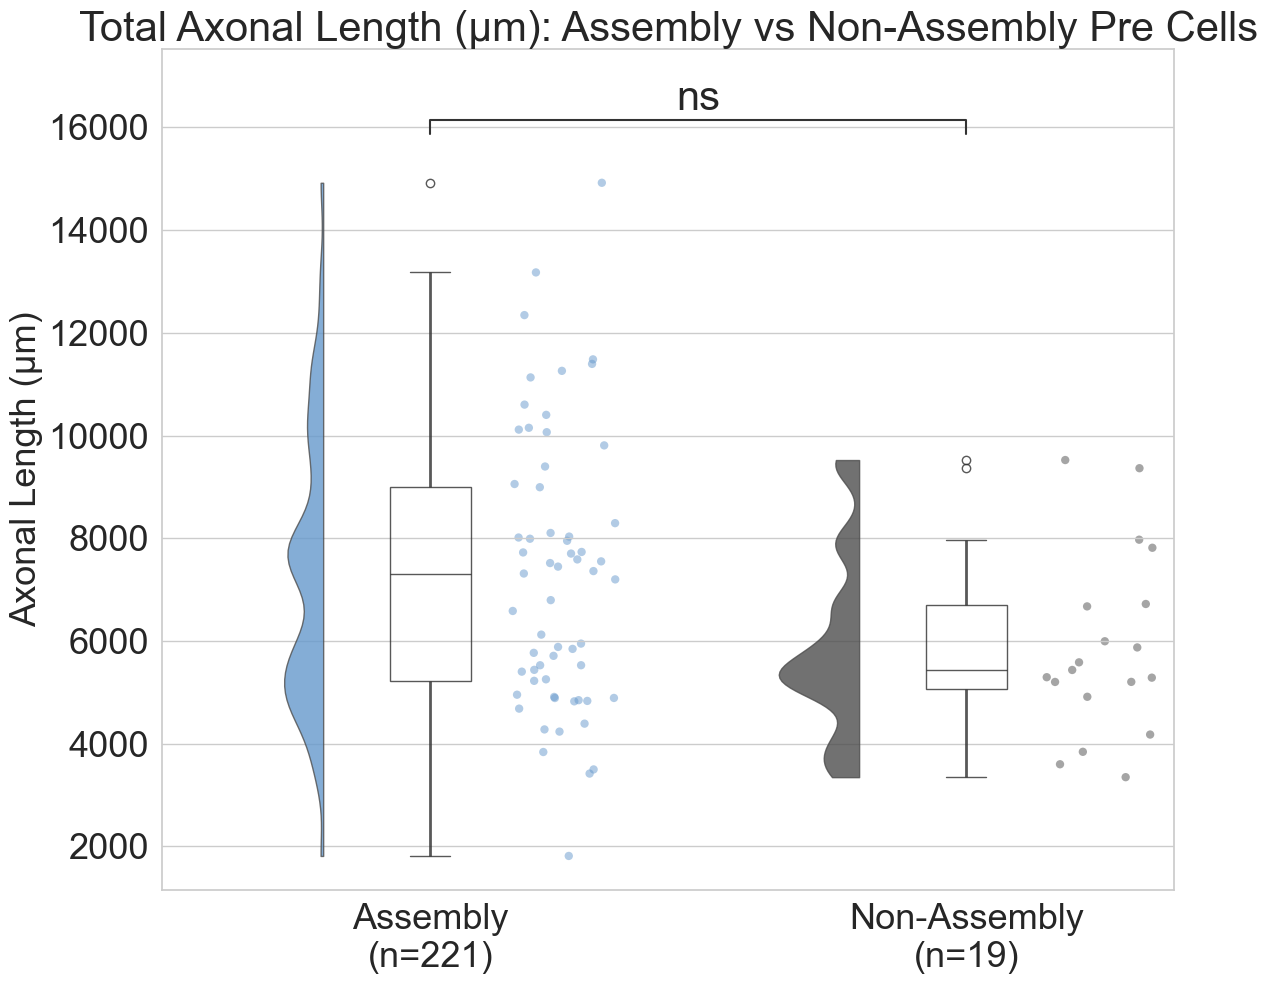

In [16]:
assembly_pre = list(pre_root_ids & assembly_root_ids)
nonassembly_pre = list(pre_root_ids & nonassembly_root_ids)

print(f"Assembly pre-cells: {len(assembly_pre)}")
print(f"Non-Assembly pre-cells: {len(nonassembly_pre)}")


# ---------------------------
# 1. Function: compute axon length from cached .npz
# ---------------------------

def compute_axon_length_from_npz(pre_id):
    """
    Computes total axonal length (µm) from cached .npz files in your format:
        coords_ax = axonal vertices (nm)
        edges_ax  = axonal edges
    """
    try:
        npz = np.load(CACHE_DIR / f"{pre_id}.npz")
        verts = npz["coords_ax"]      # (N,3) nm
        edges = npz["edges_ax"]       # (M,2)

        if verts.size == 0 or edges.size == 0:
            return 0.0

        segs = verts[edges]   # shape (M,2,3)
        lengths_nm = np.linalg.norm(segs[:,0] - segs[:,1], axis=1)

        return lengths_nm.sum() / 1000.0   # convert nm → µm

    except Exception as e:
        print(f"⚠️ Failed {pre_id}: {e}")
        return 0.0


# ---------------------------
# 2. Compute axonal lengths for all pre-cells
# ---------------------------

records = []

for cid in tqdm(pre_root_ids, desc="Computing axonal lengths"):
    axlen = compute_axon_length_from_npz(cid)
    group = "Assembly" if cid in assembly_root_ids else "NonAssembly"

    records.append({
        "cell_id": cid,
        "group": group,
        "axon_len_um": axlen
    })

axon_df = pd.DataFrame(records)

# ---------------------------
# 3. Separate into groups
# ---------------------------

assembly = axon_df[axon_df.group=="Assembly"]["axon_len_um"].values
no_assembly = axon_df[axon_df.group=="NonAssembly"]["axon_len_um"].values

print(f"Median Assembly axon length: {np.median(assembly):.1f} µm")
print(f"Median NonAssembly axon length: {np.median(no_assembly):.1f} µm")

# ---------------------------
# 4. Stats (your effect sizes)
# ---------------------------

mw_stat, mw_p = mannwhitneyu(assembly, no_assembly, alternative="two-sided", method="asymptotic")

hl  = hodges_lehmann(assembly, no_assembly, alternative="greater")
A_sh, delta = ps_and_delta(assembly, no_assembly, alternative="greater")
d   = cohens_d(assembly, no_assembly, alternative="greater")

print("\n=== AXON LENGTH TESTS ===")
print(f"Mann–Whitney U p = {mw_p:.4g}")
print(f"Hodges–Lehmann median difference = {hl:.2f} µm")
print(f"Probability of Superiority A = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")


# ---------------------------
# 5. Raincloud plot (inline)
# ---------------------------

label_A = f"Assembly\n(n={len(A)})"
label_N = f"Non-Assembly\n(n={len(no_assembly)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([assembly, no_assembly]),
    "Group": [label_A]*len(assembly) + [label_N]*len(no_assembly)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

# Significance annotation
pairs = [(label_A, label_N)]
annot = Annotator(ax,
                  pairs,
                  data=plot_df,
                  x="Group",
                  y="Values",
                  order=[label_A, label_N])

annot.set_pvalues([mw_p])
annot.configure(text_format="star",
                loc="inside",
                fontsize=30)
annot.annotate()

plt.title("Total Axonal Length (µm): Assembly vs Non-Assembly Pre Cells", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Axonal Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# shared v disjoint cotravel

Shared pairs: 4945
Disjoint pairs: 8475
Median Shared Co-Travel:   78.27 µm
Median Disjoint Co-Travel: 87.34 µm

=== SHARED vs DISJOINT COTRAVEL TESTS ===
Mann–Whitney U p = 0.9405
Hodges–Lehmann Δ = -10.19 µm
Probability of Superiority (A) = 0.444
Cliff’s delta = -0.113
Cohen’s d = -0.155
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=159): Custom statistical test, P_val:9.405e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


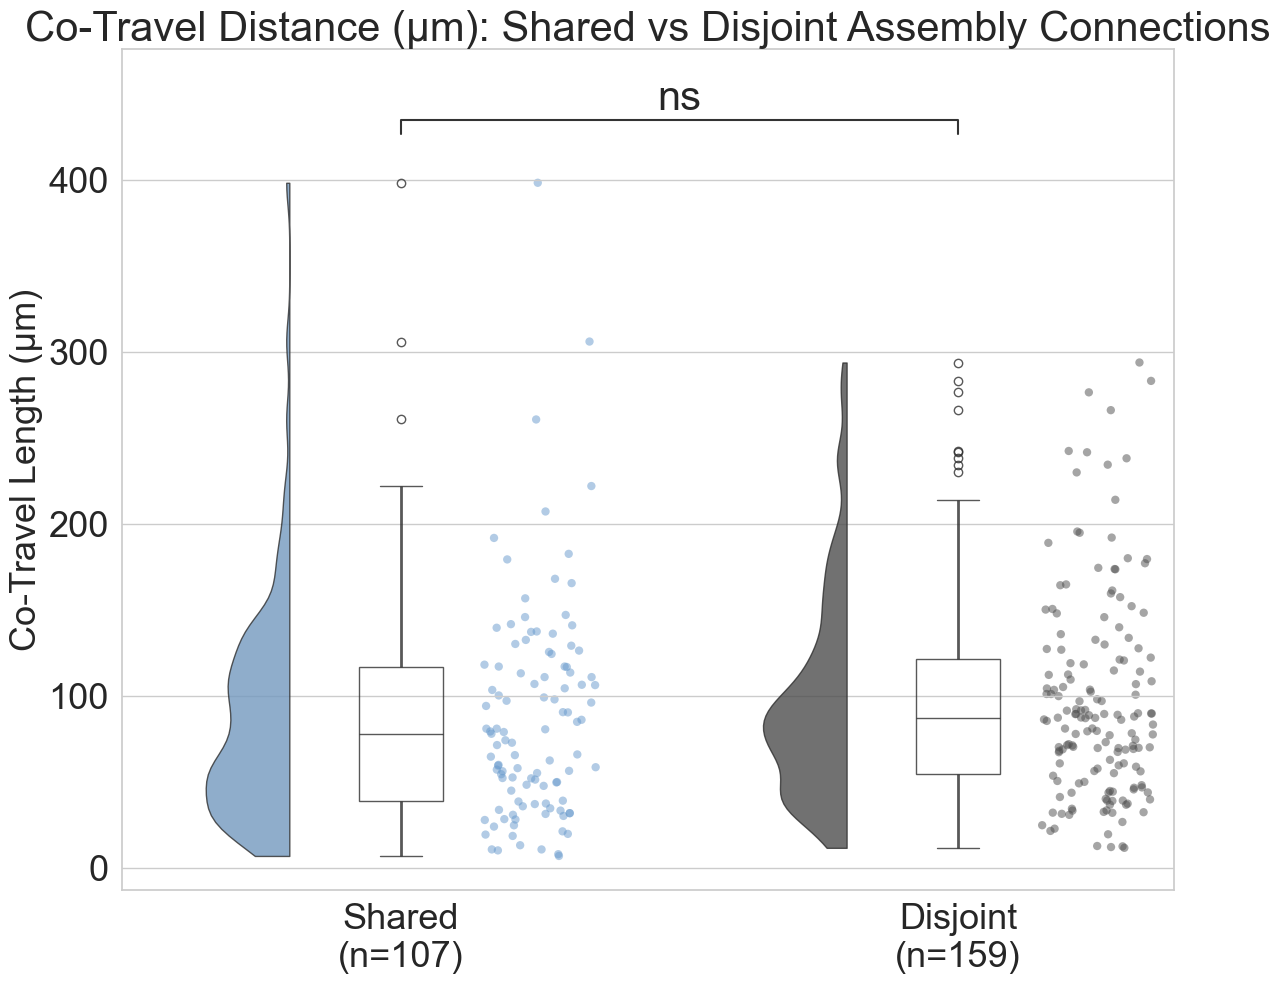

In [17]:
shared_pairs = []
disjoint_pairs = []

for (pre,post), cotravel in c.items():
    # if cotravel == 0:
    #     continue

    if shared(pre, post, A):
        shared_pairs.append((pre, post))

    elif disjoint(pre, post, A):
        disjoint_pairs.append((pre, post))

print(f"Shared pairs: {len(shared_pairs)}")
print(f"Disjoint pairs: {len(disjoint_pairs)}")

# ------------------------------------------------------
# 1. Extract cached cotravel values from dict c
# ------------------------------------------------------

shared_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_pairs], float)
disjoint_cotravel = np.array([c[(pre, post)] for (pre, post) in disjoint_pairs], float)
# nonzero
shared_cotravel = shared_cotravel[shared_cotravel > 0]
disjoint_cotravel = disjoint_cotravel[disjoint_cotravel > 0]
# Convert nm → µm
shared_cotravel = shared_cotravel / 1000.0
disjoint_cotravel = disjoint_cotravel / 1000.0

S = shared_cotravel
D = disjoint_cotravel

print(f"Median Shared Co-Travel:   {np.median(S):.2f} µm")
print(f"Median Disjoint Co-Travel: {np.median(D):.2f} µm")


# ------------------------------------------------------
# 2. Stats (using your effect-size functions)
# ------------------------------------------------------

mw_stat, mw_p = mannwhitneyu(S, D, alternative="greater", method="asymptotic")
hl = hodges_lehmann(S, D, alternative="greater")
A_sh, delta = ps_and_delta(S, D, alternative="greater")
d = cohens_d(S, D, alternative="greater")

print("\n=== SHARED vs DISJOINT COTRAVEL TESTS ===")
print(f"Mann–Whitney U p = {mw_p:.4g}")
print(f"Hodges–Lehmann Δ = {hl:.2f} µm")
print(f"Probability of Superiority (A) = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")

# ------------------------------------------------------
# 3. Raincloud Plot (inline)
# ------------------------------------------------------

label_S = f"Shared\n(n={len(S)})"
label_D = f"Disjoint\n(n={len(D)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([S, D]),
    "Group": [label_S]*len(S) + [label_D]*len(D)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    hue="Group",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

pairs = [(label_S, label_D)]
annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x="Group",
    y="Values",
    order=[label_S, label_D]
)

annot.set_pvalues([mw_p])
annot.configure(
    text_format="star",
    loc="inside",
    fontsize=30
)

annot.annotate() 

plt.title("Co-Travel Distance (µm): Shared vs Disjoint Assembly Connections", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Co-Travel Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# shared a v shared no a cotravel length

Assembly pairs: 13420
No Assembly pairs: 1767
Median Shared Co-Travel:   81.32 µm
Median Disjoint Co-Travel: 51.47 µm

=== SHARED A vs SHARED NO A COTRAVEL TESTS ===
Mann–Whitney U p = 0.03187
Hodges–Lehmann Δ = 20.39 µm
Probability of Superiority (A) = 0.614
Cliff’s delta = 0.229
Cohen’s d = 0.315
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Both A
(n=266) vs. Both No A
(n=24): Custom statistical test, P_val:3.187e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


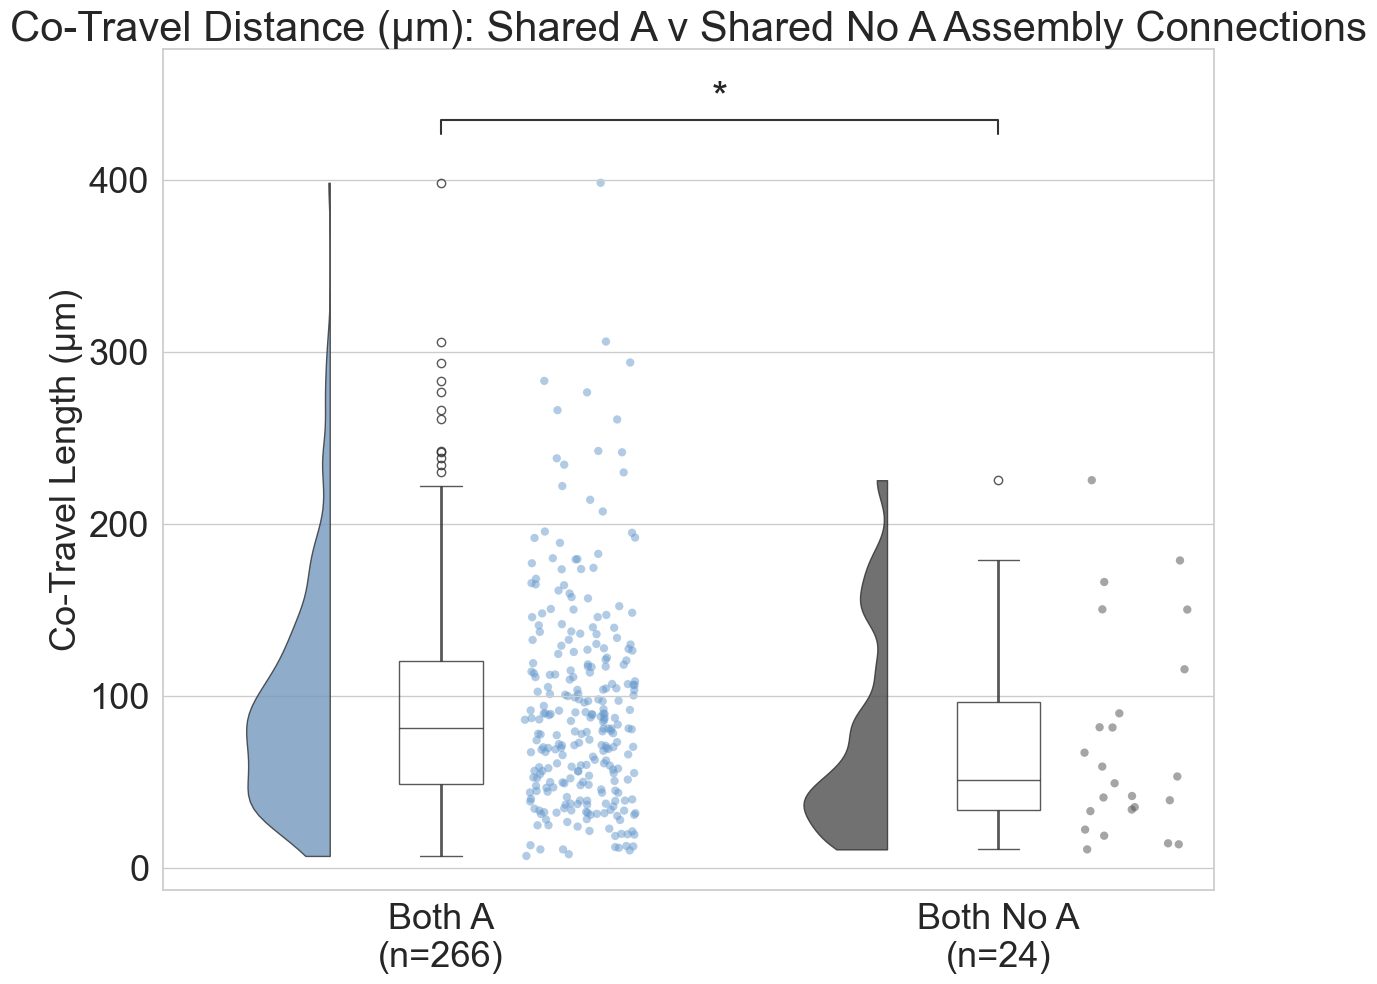

In [18]:
shared_a_pairs = []
shared_no_a_pairs = []

for (pre,post), cotravel in c.items():
    # if cotravel == 0:
    #     continue

    if shared_a(pre, post, A):
        shared_a_pairs.append((pre, post))

    elif shared_no_a(pre, post, A):
        shared_no_a_pairs.append((pre, post))

print(f"Assembly pairs: {len(shared_a_pairs)}")
print(f"No Assembly pairs: {len(shared_no_a_pairs)}")

# ------------------------------------------------------
# 1. Extract cached cotravel values from dict c
# ------------------------------------------------------

a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_a_pairs], float)
no_a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_no_a_pairs], float)
# nonzero
a_cotravel = a_cotravel[a_cotravel > 0]
no_a_cotravel = no_a_cotravel[no_a_cotravel > 0]
# Convert nm → µm
a_cotravel = a_cotravel / 1000.0
no_a_cotravel = no_a_cotravel / 1000.0

S = a_cotravel
D = no_a_cotravel

print(f"Median Shared Co-Travel:   {np.median(S):.2f} µm")
print(f"Median Disjoint Co-Travel: {np.median(D):.2f} µm")


# ------------------------------------------------------
# 2. Stats (using your effect-size functions)
# ------------------------------------------------------

mw_stat, mw_p = mannwhitneyu(S, D, alternative="greater", method="asymptotic")
hl = hodges_lehmann(S, D, alternative="greater")
A_sh, delta = ps_and_delta(S, D, alternative="greater")
d = cohens_d(S, D, alternative="greater")

print("\n=== SHARED A vs SHARED NO A COTRAVEL TESTS ===")
print(f"Mann–Whitney U p = {mw_p:.4g}")
print(f"Hodges–Lehmann Δ = {hl:.2f} µm")
print(f"Probability of Superiority (A) = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")

# ------------------------------------------------------
# 3. Raincloud Plot (inline)
# ------------------------------------------------------

label_S = f"Both A\n(n={len(S)})"
label_D = f"Both No A\n(n={len(D)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([S, D]),
    "Group": [label_S]*len(S) + [label_D]*len(D)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    hue="Group",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

pairs = [(label_S, label_D)]
annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x="Group",
    y="Values",
    order=[label_S, label_D]
)

annot.set_pvalues([mw_p])
annot.configure(
    text_format="star",
    loc="inside",
    fontsize=30
)

annot.annotate() 

plt.title("Co-Travel Distance (µm): Shared A v Shared No A Assembly Connections", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Co-Travel Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# Synaptic Count Distributions By Connection Type

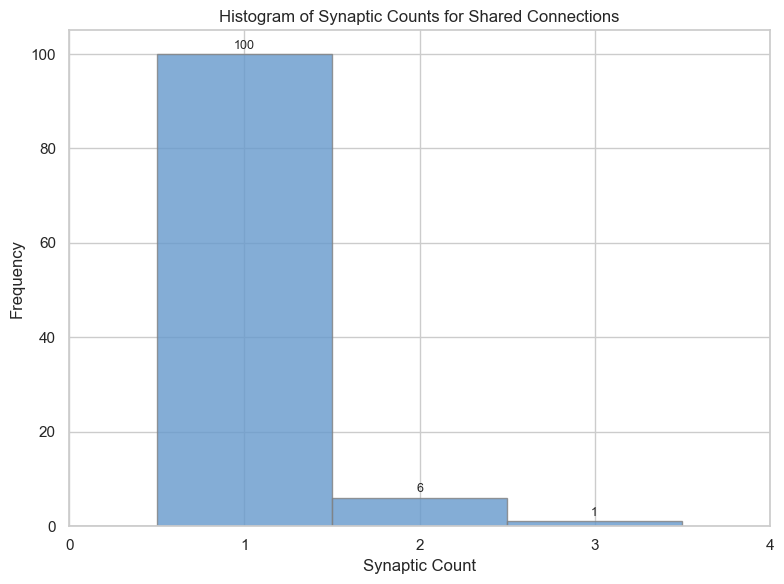

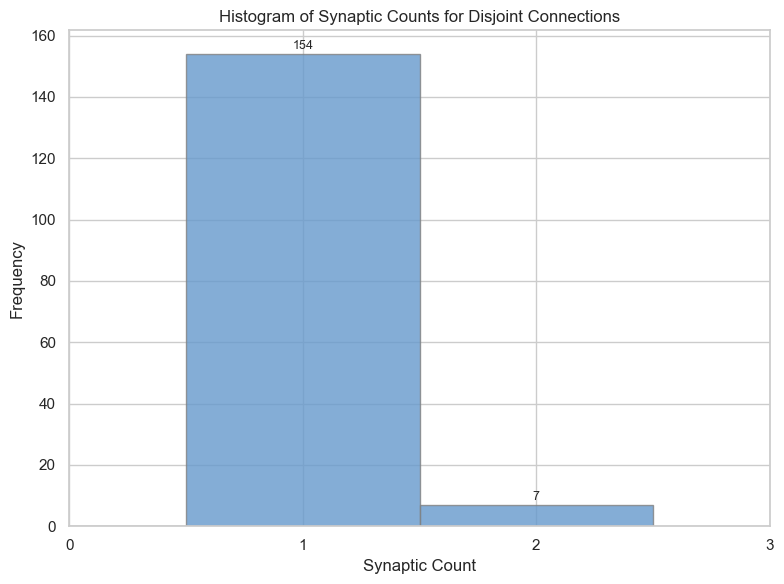

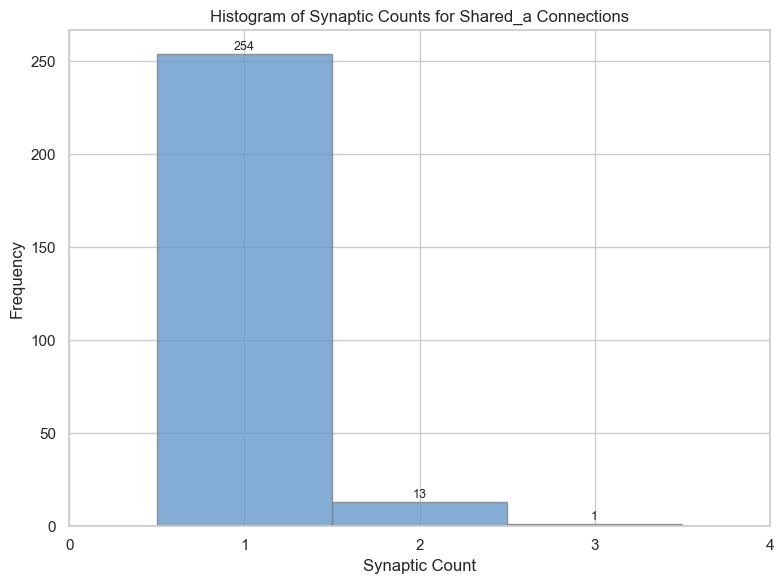

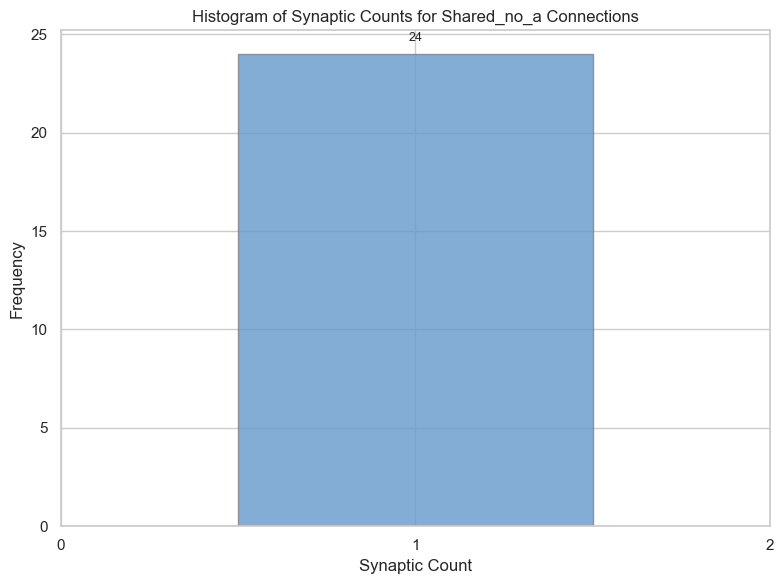

In [19]:
for group in groups:
    synaptic_count_histogram(
        values_dict=S_nonzero_pairwise[group],
        connection_type=group,
        save=False,
        figure_name=None
    )

# Normalized Synaptic Counts (Mirrored to PSD)

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3098, P-value: 0.3784

[UNPAIRED] Effect sizes (pos = 'greater')  n1=107, n2=161
  Test p-value: 0.2114
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.078])
    Cohen's d: 0.127 : CI [-0.111, 0.353]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.079])
    Cohen's d: 0.127 : CI [-0.109, 0.359]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


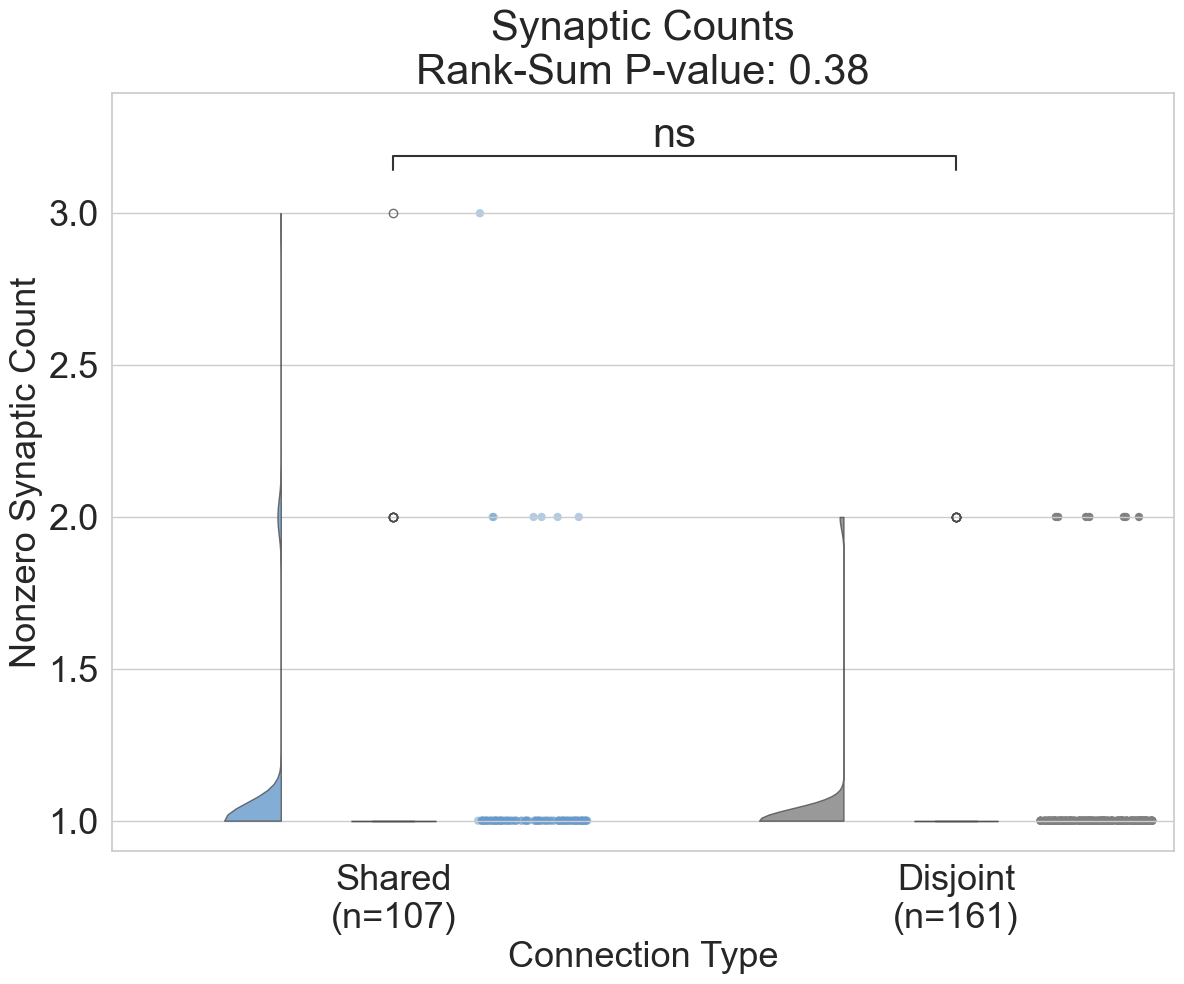

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


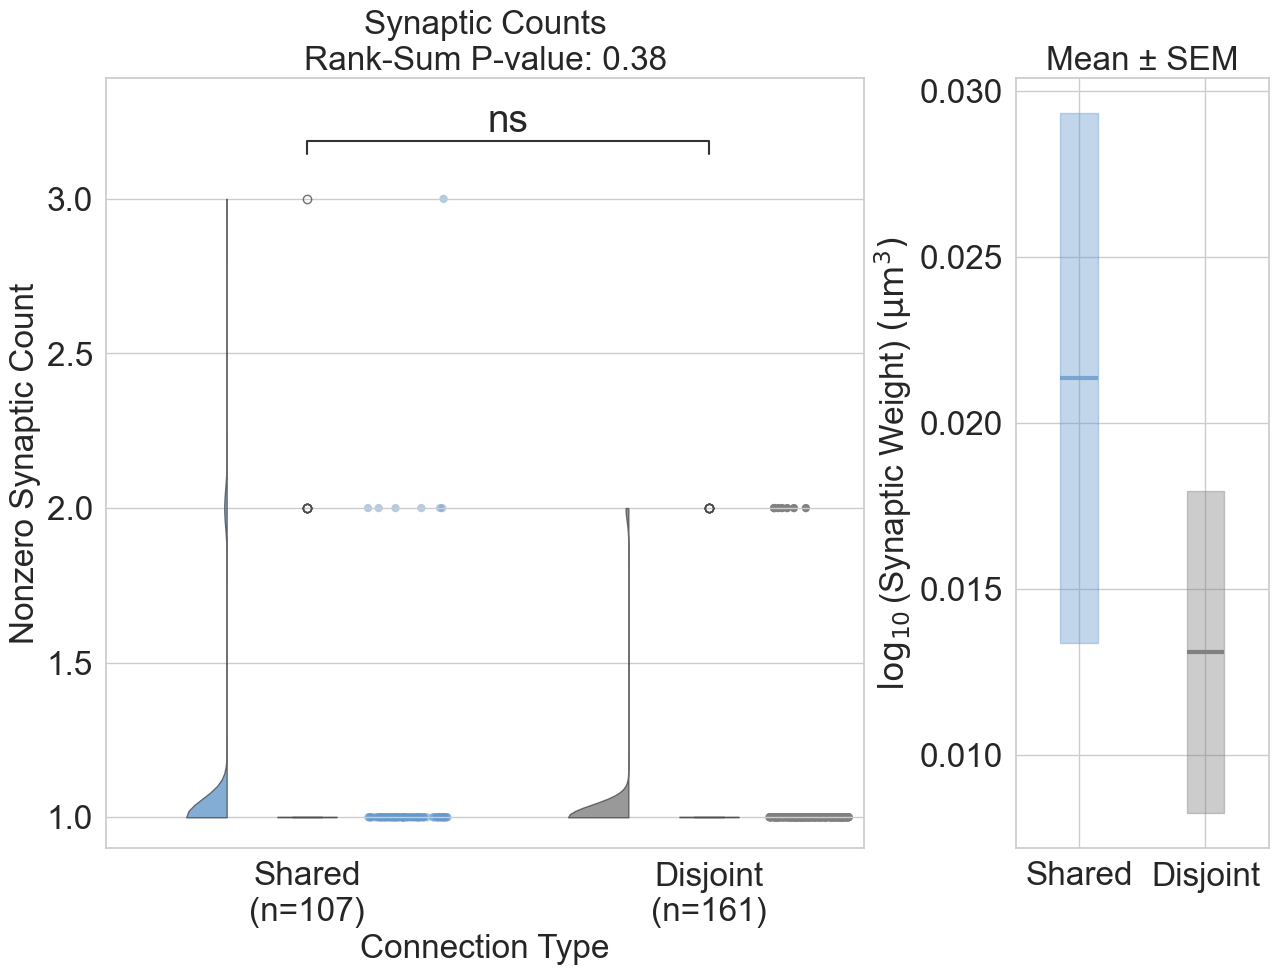

In [20]:
ranksum_signedrank_two_group_comparison(S_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3555, P-value: 0.3611


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:131: RuntimeWarning: invalid value encountered in scalar mu


[UNPAIRED] Effect sizes (pos = 'greater')  n1=39, n2=53
  Test p-value: 0.274
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.455, 0.595]   (δ=0.044 : CI [-0.090, 0.189])
    Cohen's d: 0.210 : CI [-0.267, 0.550]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.456, 0.596]   (δ=0.044 : CI [-0.089, 0.192])
    Cohen's d: 0.210 : CI [-0.231, 0.578]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 17.5, P-value: 0.2767

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=33
  Test p-value: 0.2767
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : CI [0.439, 0.591]   (δ=0.030 : CI [-0.121, 0.182])
    Cohen's d: 0.129 : CI [-0.256, 0.394]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : 

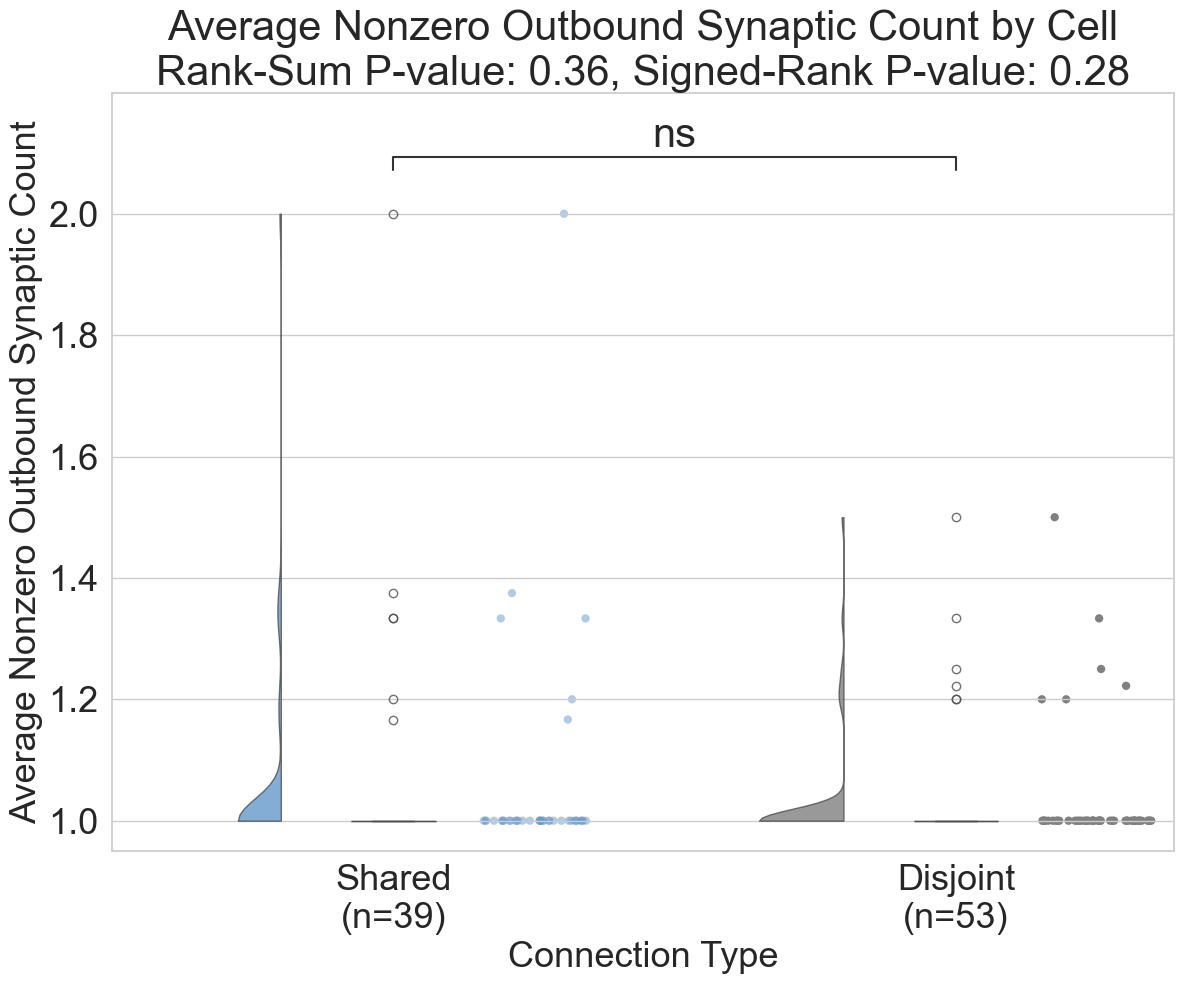

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


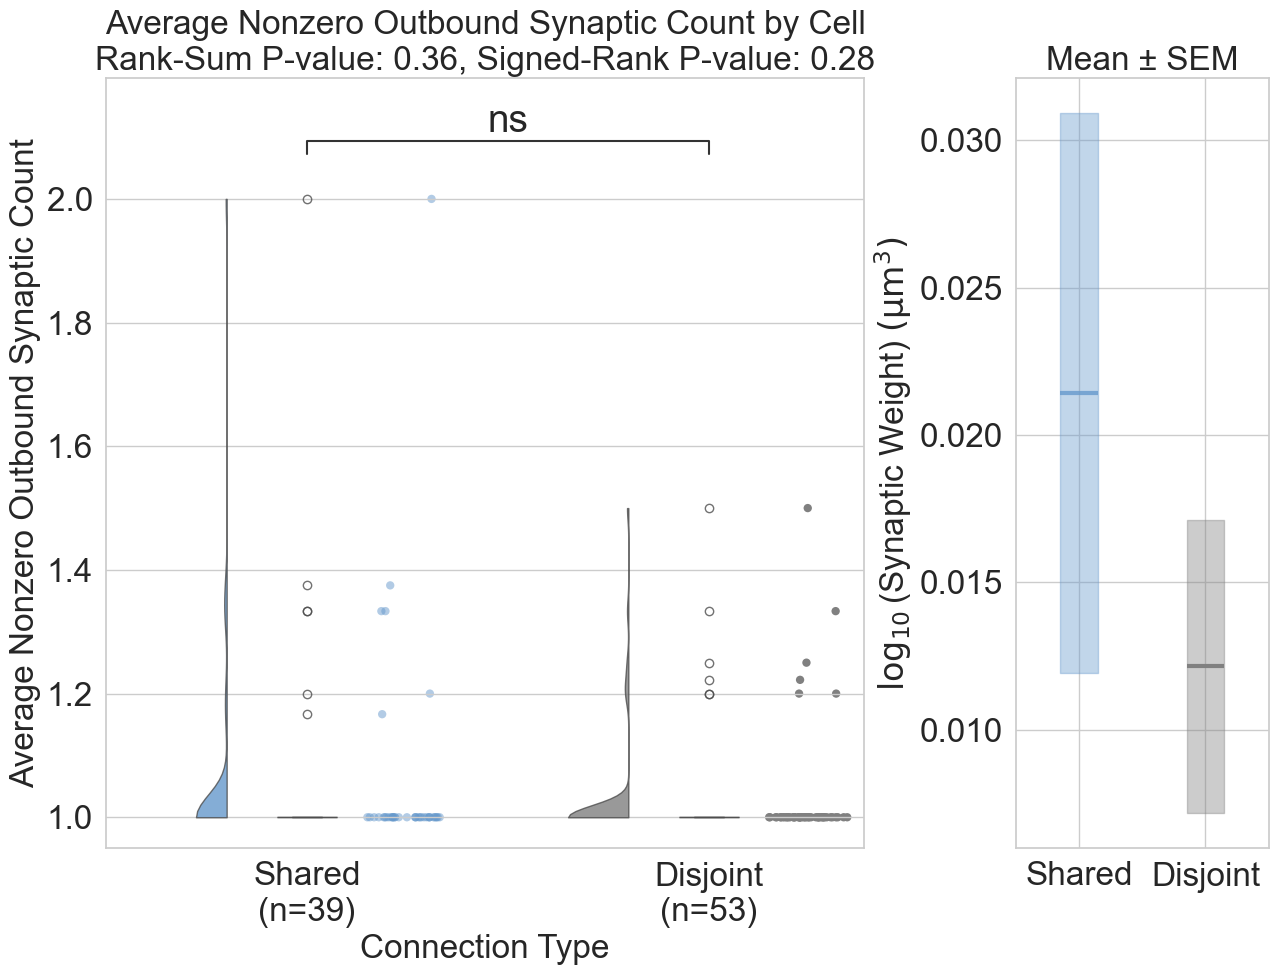

In [21]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.4394, P-value: 0.3302


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\548594465.py:131: RuntimeWarning: invalid value encountered in scalar mu


[UNPAIRED] Effect sizes (pos = 'greater')  n1=71, n2=103
  Test p-value: 0.1684
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.480, 0.563]   (δ=0.039 : CI [-0.040, 0.126])
    Cohen's d: 0.143 : CI [-0.195, 0.416]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.485, 0.571]   (δ=0.039 : CI [-0.030, 0.143])
    Cohen's d: 0.143 : CI [-0.147, 0.469]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 13, P-value: 0.2981

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=39
  Test p-value: 0.2981
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : CI [0.462, 0.590]   (δ=0.051 : CI [-0.077, 0.179])
    Cohen's d: 0.105 : CI [-0.217, 0.362]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : 

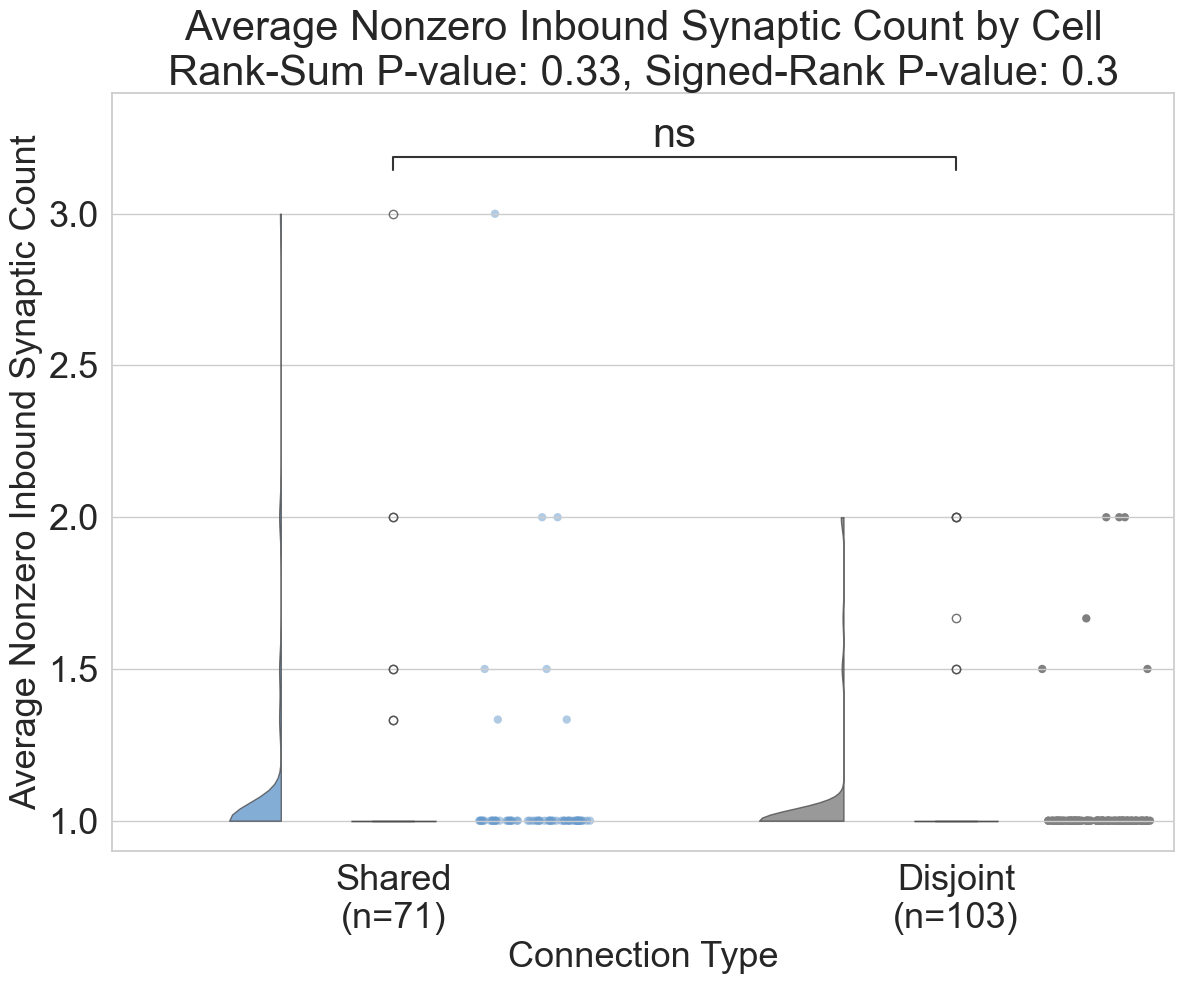

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


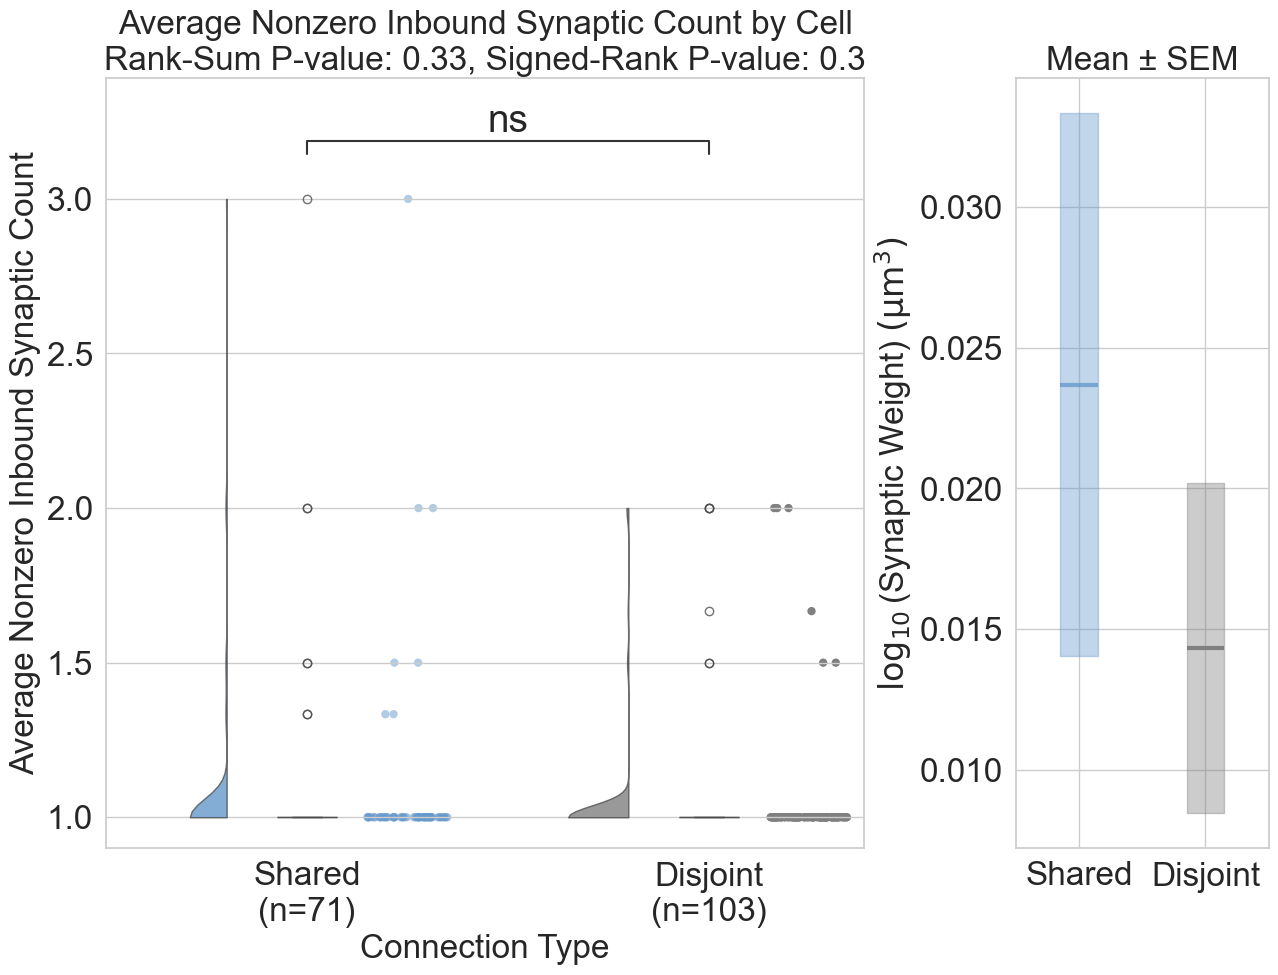

In [22]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

# Chains: Standard

In [23]:
with open('all_cells_proofread_connectome.json') as f:
    loaded_json = json.load(f)
my_data = LSMMData.LSMMData(loaded_json)
# with open('pyr_rect.data', 'wb') as f:
#     pickle.dump(my_data, f)

data_a = my_data.data
params_a = my_data.params
dirs_a = my_data.dirs
mappings_a = my_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:35<00:00, 1449.52it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:37<00:00, 1411.08it/s]


In [28]:
# Make a graph
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index

synapse_table = data_a['structural']['synapse']
# adjacency_matrix = data_a['structural']['binary_connectome']
binary_connectome = data_a['structural']['binary_connectome']

index_to_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]

summed_size_connectome = data_a['structural']['summed_size_connectome']
summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_root_id,
    columns=index_to_root_id
)

synapse_count_connectome = data_a['structural']['synapse_count_connectome']
synapse_count_connectome_df = pd.DataFrame(
    synapse_count_connectome,
    index=index_to_root_id,
    columns=index_to_root_id
)

pyr_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)
pyr_graph = nx.relabel_nodes(pyr_graph, {i: index_to_root_id[i] for i in range(len(index_to_root_id))})

# Or uncomment below to generate new motif analysis results (Can take quite a while on larger graphs)
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= pyr_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

### Pool necessary Data
chain_count_string_array = ['pyr_cell_2chain']
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()
no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']
pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))

assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]

# Filter cell tables to only assembly cells (including 'No A')
assembly_cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
assembly_post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

assembly_pre_root_ids = set(assembly_cell_table['pt_root_id'].values)
assembly_post_root_ids = set(assembly_post_cell_table['pt_root_id'].values)
all_root_ids = assembly_pre_root_ids | assembly_post_root_ids

100%|██████████| 6052393/6052393 [00:10<00:00, 564349.47it/s] 


In [29]:
# Initialize dictionaries to store weights and binary connectivity
W_chain_excitatory = {}
W_chain_inhibitory = {}
B_chain_excitatory = {}
B_chain_inhibitory = {}
S_chain_excitatory = {}
S_chain_inhibitory = {}

# Define all potential (pre-cell, post-cell) pairs with excitatory and inhibitory chain types
for j in all_root_ids:
    for i in all_root_ids:
        if j != i:  # Exclude autapses
            W_chain_excitatory[(j, i)] = 0
            W_chain_inhibitory[(j, i)] = 0
            B_chain_excitatory[(j, i)] = 0
            B_chain_inhibitory[(j, i)] = 0
            S_chain_excitatory[(j, i)] = 0
            S_chain_inhibitory[(j, i)] = 0

pt_root_id_to_classification = cell_table.set_index('pt_root_id')['classification_system'].to_dict()

# Process each row in `two_chain_results_array` to populate weights and binary connectivity
for _, row in enumerate(two_chain_results_array):
    pre_cell, mid_cell, post_cell = row  # j: pre-cell, k: middle cell, i: post-cell
    if pre_cell in all_root_ids and post_cell in all_root_ids:
    # Determine chain type (excitatory if middle cell is in excitatory set, else inhibitory)
        if pt_root_id_to_classification[mid_cell] == 'inhibitory':
            W_chain = W_chain_inhibitory
            B_chain = B_chain_inhibitory
            S_chain = S_chain_inhibitory

        elif pt_root_id_to_classification[mid_cell] == 'excitatory':
            W_chain = W_chain_excitatory
            B_chain = B_chain_excitatory
            S_chain = S_chain_excitatory

    # Get synapse weights for connections j -> k and k -> i
        w_jk = summed_size_connectome_df.loc[pre_cell, mid_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers
        w_ki = summed_size_connectome_df.loc[mid_cell, post_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers

        s_jk = synapse_count_connectome_df.loc[pre_cell, mid_cell]
        s_ki = synapse_count_connectome_df.loc[mid_cell, post_cell]
    # Updates weights and binary connectivity
        W_chain[(pre_cell, post_cell)] += (w_jk * w_ki)
        B_chain[(pre_cell, post_cell)] = 1
        S_chain[(pre_cell, post_cell)] += (s_jk * s_ki)

In [32]:
## PARIWISE NONZERO PSD and CONNECTION PROBABILITY BY CONNECTION TYPE
# Aggregate nonzero pairs and calculate connectivity probabilities by connection type
W_chain_nonzero_pairwise_excitatory = {}
W_chain_nonzero_pairwise_inhibitory = {}
B_chain_pairwise_excitatory = {}
B_chain_pairwise_inhibitory = {}
S_chain_pairwise_excitatory = {}
S_chain_pairwise_inhibitory = {}

for cond_function in comparison_functions:
    # Initialize dictionaries per connection type
    W_chain_nonzero_pairwise_excitatory[cond_function.__name__] = {}
    W_chain_nonzero_pairwise_inhibitory[cond_function.__name__] = {}
    B_chain_pairwise_excitatory[cond_function.__name__] = {}
    B_chain_pairwise_inhibitory[cond_function.__name__] = {}
    S_chain_pairwise_excitatory[cond_function.__name__] = {}
    S_chain_pairwise_inhibitory[cond_function.__name__] = {}

    # Process all (j, i) pairs from excitatory/inhibitory dictionaries
    for (j, i) in W_chain_excitatory.keys():
        if cond_function(j, i, A):
            # Set binary connectivity for each connection type
            B_chain_pairwise_excitatory[cond_function.__name__][(j, i)] = 1 if W_chain_excitatory[(j, i)] > 0 else 0
            B_chain_pairwise_inhibitory[cond_function.__name__][(j, i)] = 1 if W_chain_inhibitory[(j, i)] > 0 else 0
            S_chain_pairwise_excitatory[cond_function.__name__][(j, i)] = 1 if W_chain_excitatory[(j, i)] > 0 else 0
            S_chain_pairwise_inhibitory[cond_function.__name__][(j, i)] = 1 if W_chain_inhibitory[(j, i)] > 0 else 0
            # Store only nonzero weights
            if W_chain_excitatory[(j, i)] > 0:
                W_chain_nonzero_pairwise_excitatory[cond_function.__name__][(j, i)] = W_chain_excitatory[(j, i)]
            if W_chain_inhibitory[(j, i)] > 0:
                W_chain_nonzero_pairwise_inhibitory[cond_function.__name__][(j, i)] = W_chain_inhibitory[(j, i)]

## ADD IN NORMALIZATION BY # POTENTIAL CONNECTIONS
## Inbound, Outbound Collections
from collections import Counter

classification_map = cell_table.set_index('connectome_index')['classification_system'].to_dict() # Map to tell us if its Excitatory or Inhibitory 
backup_assembly_pre_root_ids = assembly_pre_root_ids
backup_assembly_post_root_ids = assembly_post_root_ids
classification_counts = Counter(classification_map.values())

num_excitatory = classification_counts.get('excitatory', 0)
num_inhibitory = classification_counts.get('inhibitory', 0)
# Aggregate chain weights and connectivity for outbound and inbound paths
W_nonzero_chain_out_excitatory = {}
W_nonzero_chain_out_inhibitory = {}
W_nonzero_chain_in_excitatory = {}
W_nonzero_chain_in_inhibitory = {}
B_chain_out_excitatory = {}
B_chain_out_inhibitory = {}
B_chain_in_excitatory = {}
B_chain_in_inhibitory = {}
S_chain_out_excitatory = {}
S_chain_out_inhibitory = {}
S_chain_in_excitatory = {}
S_chain_in_inhibitory = {}

# Iterate through connection types in C (e.g., shared, disjoint)
for connection_type in comparison_functions:
    # Initialize per connection type dictionaries
    W_nonzero_chain_out_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_out_inhibitory[connection_type.__name__] = {}
    W_nonzero_chain_in_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_in_inhibitory[connection_type.__name__] = {}
    B_chain_out_excitatory[connection_type.__name__] = {}
    B_chain_out_inhibitory[connection_type.__name__] = {}
    B_chain_in_excitatory[connection_type.__name__] = {}
    B_chain_in_inhibitory[connection_type.__name__] = {}
    S_chain_out_excitatory[connection_type.__name__] = {}
    S_chain_out_inhibitory[connection_type.__name__] = {}
    S_chain_in_excitatory[connection_type.__name__] = {}
    S_chain_in_inhibitory[connection_type.__name__] = {}

    # Outbound analysis (from pre-cell j to post-cell i through middle cell k)
    for j in all_root_ids:
        potential_partners_out = {i for i in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_out:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            sum_synapses_excitatory = 0
            sum_synapses_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_out)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_out)
            for i in potential_partners_out:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]

                    s_jk = synapse_count_connectome_df.loc[j, k]
                    s_ki = synapse_count_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        sum_synapses_excitatory += s_jk * s_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        sum_synapses_inhibitory += s_jk * s_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_out_excitatory[connection_type.__name__][j] = sum_weights_excitatory / realized_chains_count_excitatory
                S_chain_out_excitatory[connection_type.__name__][j] = sum_synapses_excitatory / realized_chains_count_excitatory
        
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_out_inhibitory[connection_type.__name__][j] = sum_weights_inhibitory / realized_chains_count_inhibitory
                S_chain_out_inhibitory[connection_type.__name__][j] = sum_synapses_inhibitory / realized_chains_count_inhibitory
            # Calculate binary connectivity only if there are potential partners
            B_chain_out_excitatory[connection_type.__name__][j] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_out) > 0 else 0
            B_chain_out_inhibitory[connection_type.__name__][j] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_out) > 0 else 0

    for i in all_root_ids:
        potential_partners_in = {j for j in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_in:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_in)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_in)
            for j in potential_partners_in:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]

                    s_jk = synapse_count_connectome_df.loc[j, k]
                    s_ki = synapse_count_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        sum_synapses_excitatory += s_jk * s_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        sum_synapses_inhibitory += s_jk * s_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_in_excitatory[connection_type.__name__][i] = sum_weights_excitatory / realized_chains_count_excitatory
                S_chain_in_excitatory[connection_type.__name__][j] = sum_synapses_excitatory / realized_chains_count_excitatory
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_in_inhibitory[connection_type.__name__][i] = sum_weights_inhibitory / realized_chains_count_inhibitory
                S_chain_in_inhibitory[connection_type.__name__][j] = sum_synapses_inhibitory / realized_chains_count_inhibitory

            # Calculate binary connectivity only if there are potential partners
            B_chain_in_excitatory[connection_type.__name__][i] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_in) > 0 else 0
            B_chain_in_inhibitory[connection_type.__name__][i] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_in) > 0 else 0

# plots

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3382, P-value: 0.3676

[UNPAIRED] Effect sizes (pos = 'greater')  n1=239, n2=307
  Test p-value: 0.3677
  Shared median = 3.946e-05, Disjoint median = 3.68207e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 9.39335e-07 : CI [-5.24246e-06, 7.54562e-06]
    PS:       0.508 : CI [0.462, 0.561]   (δ=0.017 : CI [-0.076, 0.122])
    Cohen's d: -0.048 : CI [-0.216, 0.130]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 9.39335e-07 : CI [-5.47049e-06, 7.31481e-06]
    PS:       0.508 : CI [0.459, 0.559]   (δ=0.017 : CI [-0.082, 0.117])
    Cohen's d: -0.048 : CI [-0.217, 0.129]


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


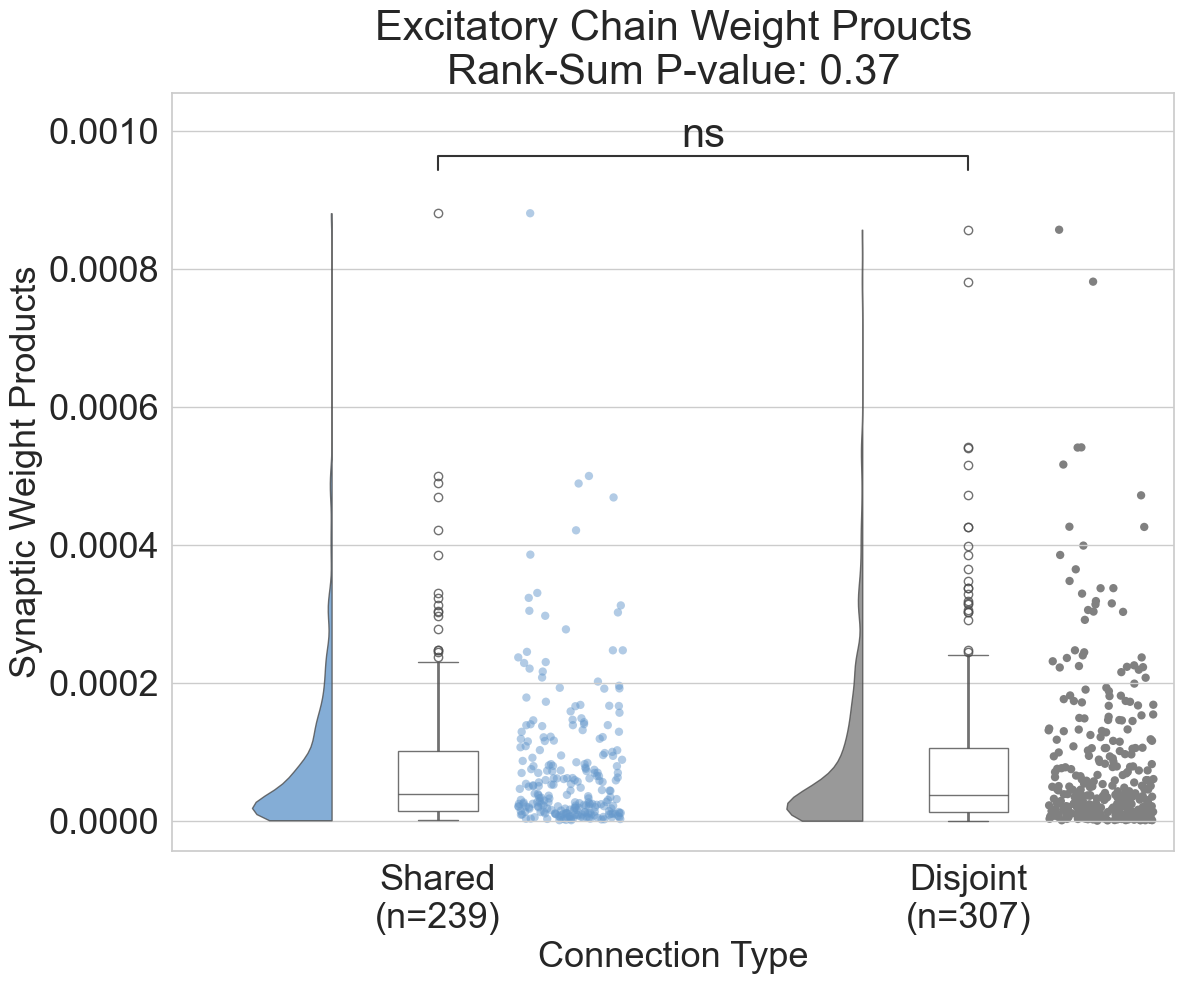

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


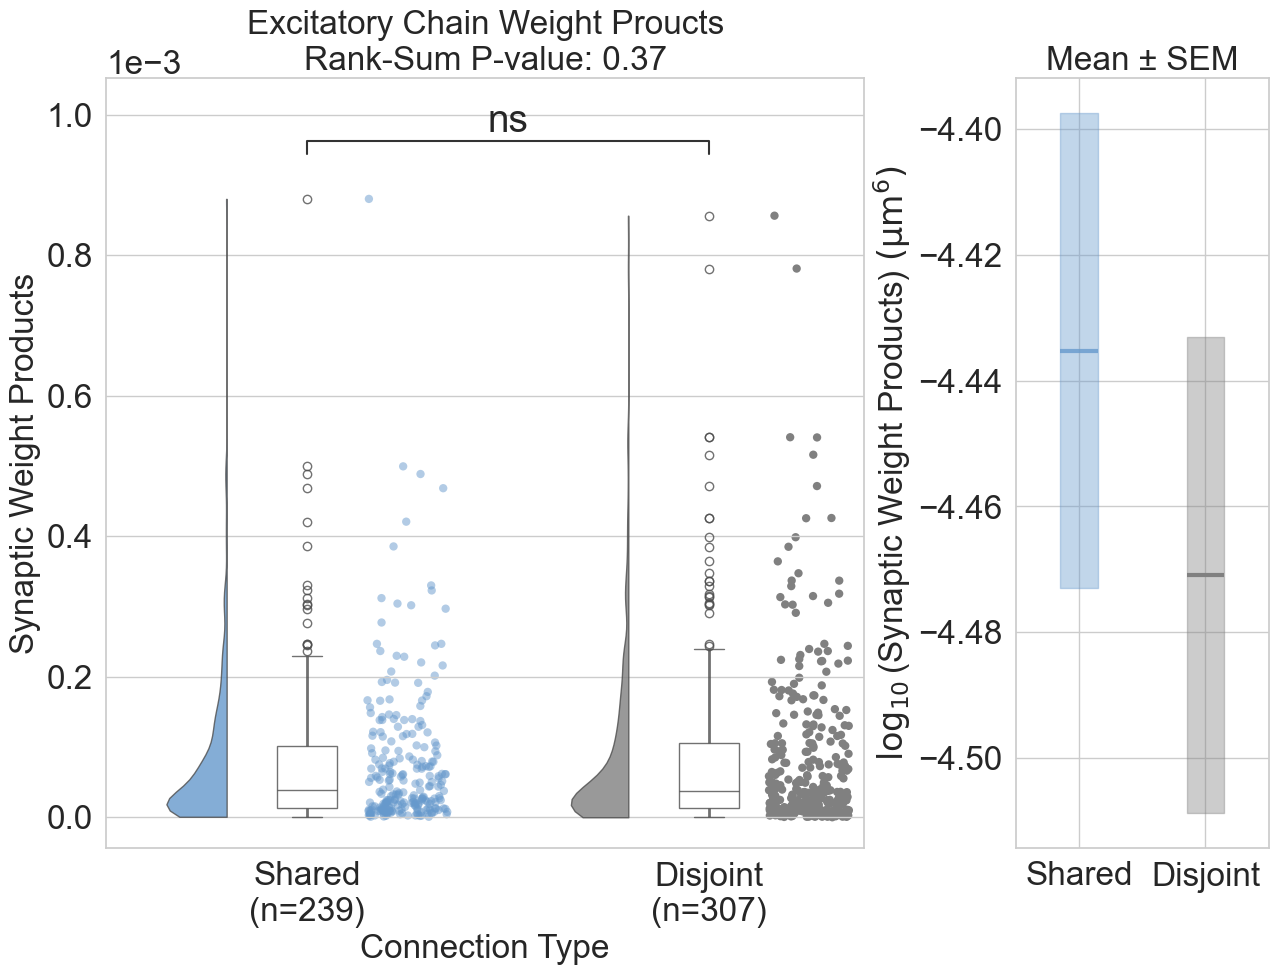

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -2.302, P-value: 0.01066

[UNPAIRED] Effect sizes (pos = 'less')  n1=1608, n2=2049
  Test p-value: 0.01066
  Shared median = 0.000698374, Disjoint median = 0.000719536

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 3.88568e-05 : CI [7.47329e-06, 7.16734e-05]
    PS:       0.522 : CI [0.504, 0.542]   (δ=0.044 : CI [0.008, 0.083])
    Cohen's d: 0.071 : CI [0.010, 0.136]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 3.88568e-05 : CI [7.47658e-06, 7.16228e-05]
    PS:       0.522 : CI [0.504, 0.542]   (δ=0.044 : CI [0.008, 0.083])
    Cohen's d: 0.071 : CI [0.008, 0.135]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


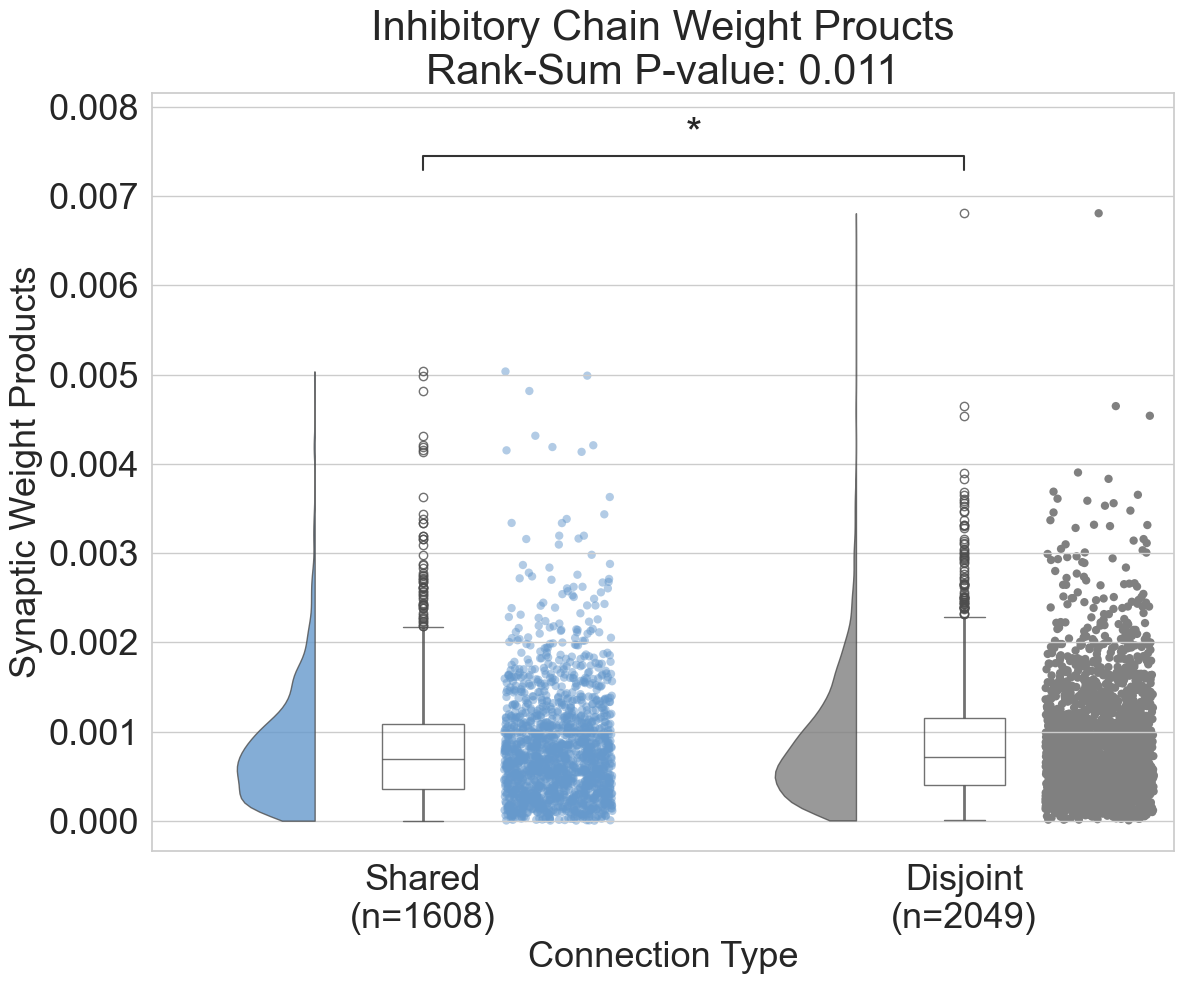

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


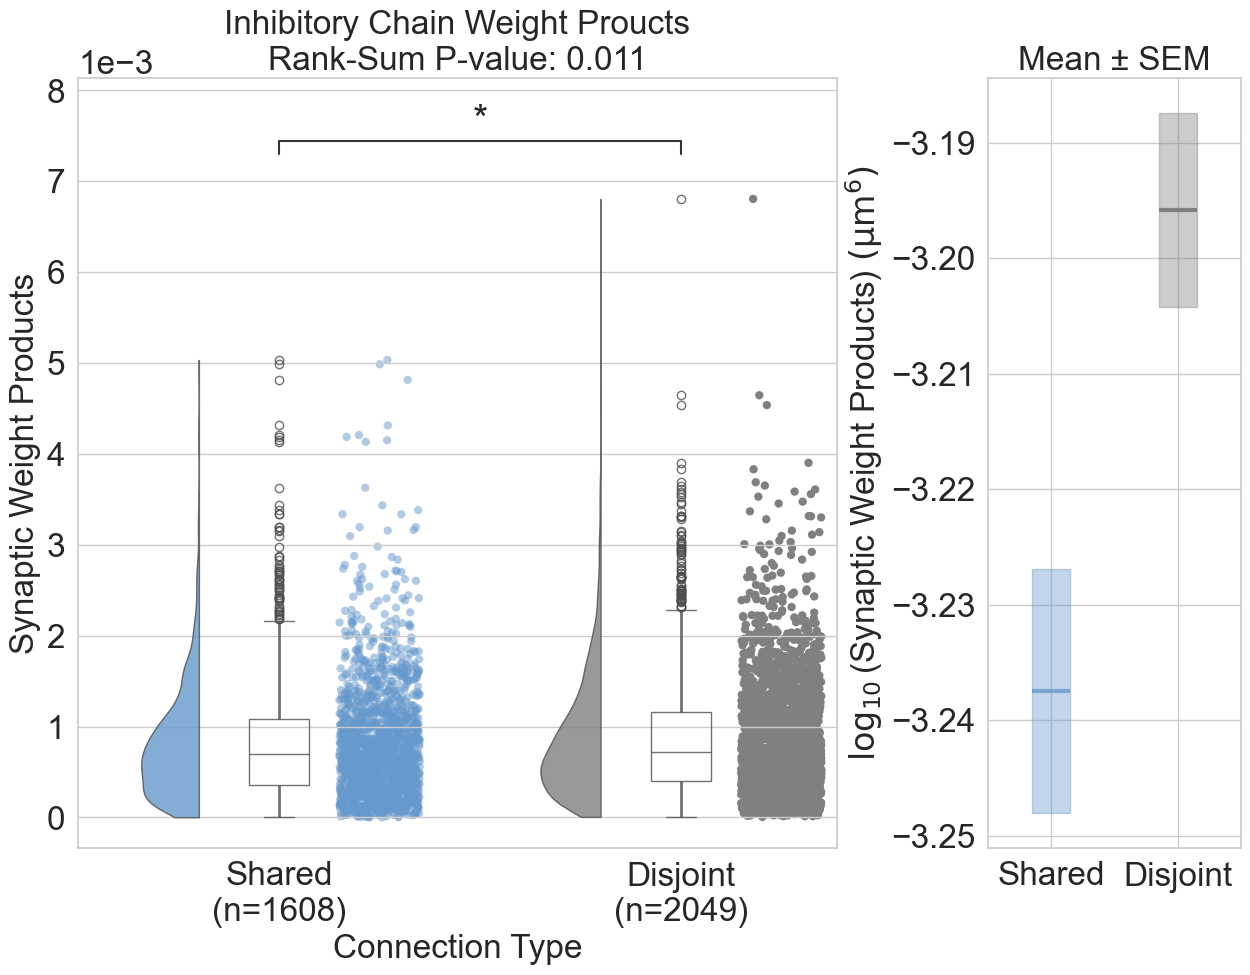

In [33]:
ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_excitatory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_E_Chain'
                                        )


ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_inhibitory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_I_Chain'
                                        )

# Subsampling:

SUBSAMPLED
Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.106, P-value: 0.1343

[UNPAIRED] Effect sizes (pos = 'less')  n1=239, n2=307
  Test p-value: 0.1343
  Shared median = 0.000632796, Disjoint median = 0.000726464

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 4.75498e-05 : CI [-3.67543e-05, 0.000137155]
    PS:       0.528 : CI [0.479, 0.577]   (δ=0.055 : CI [-0.043, 0.154])
    Cohen's d: 0.063 : CI [-0.111, 0.243]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 4.75498e-05 : CI [-2.95255e-05, 0.000141636]
    PS:       0.528 : CI [0.483, 0.581]   (δ=0.055 : CI [-0.035, 0.162])
    Cohen's d: 0.063 : CI [-0.108, 0.252]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


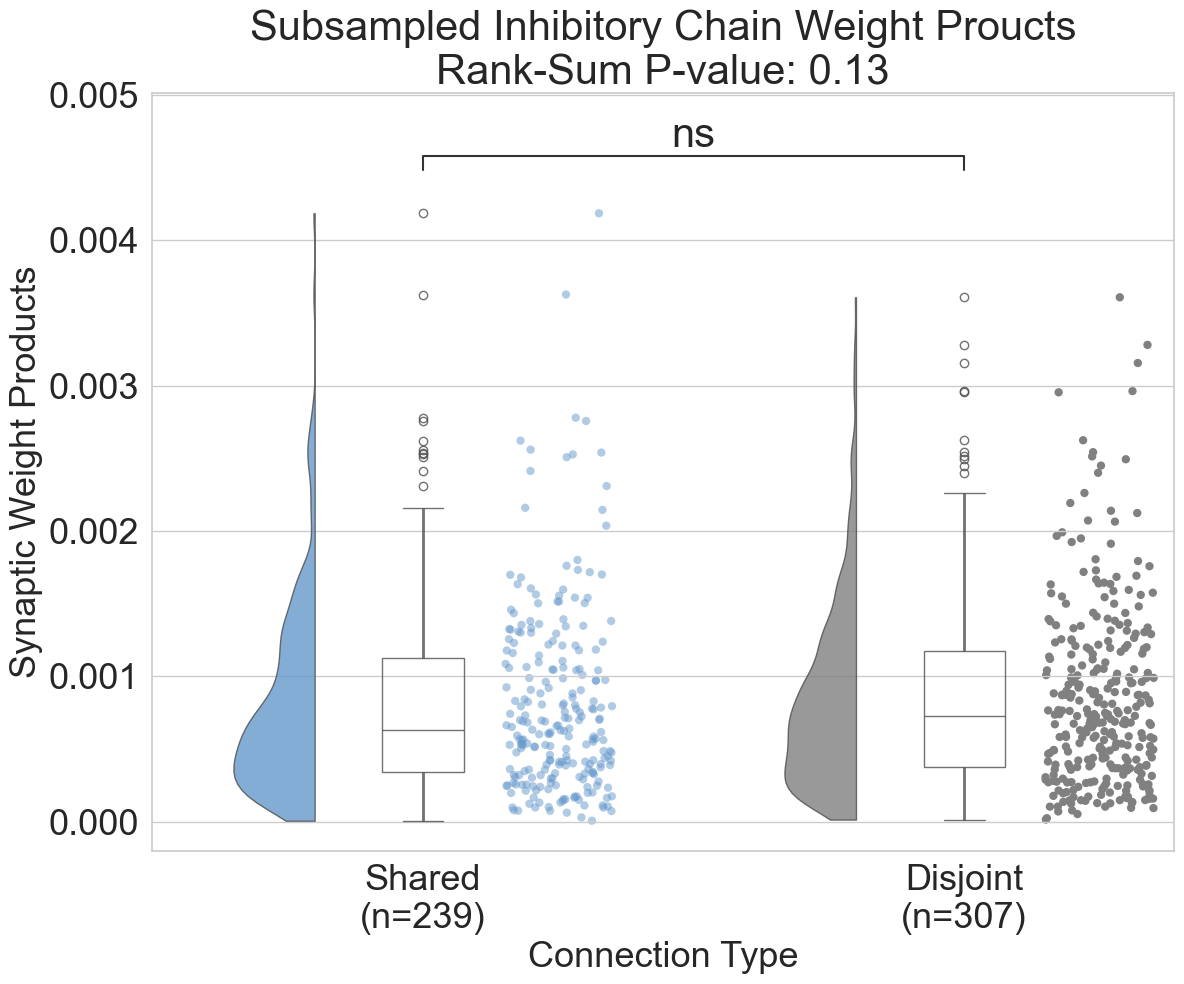

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_15672\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


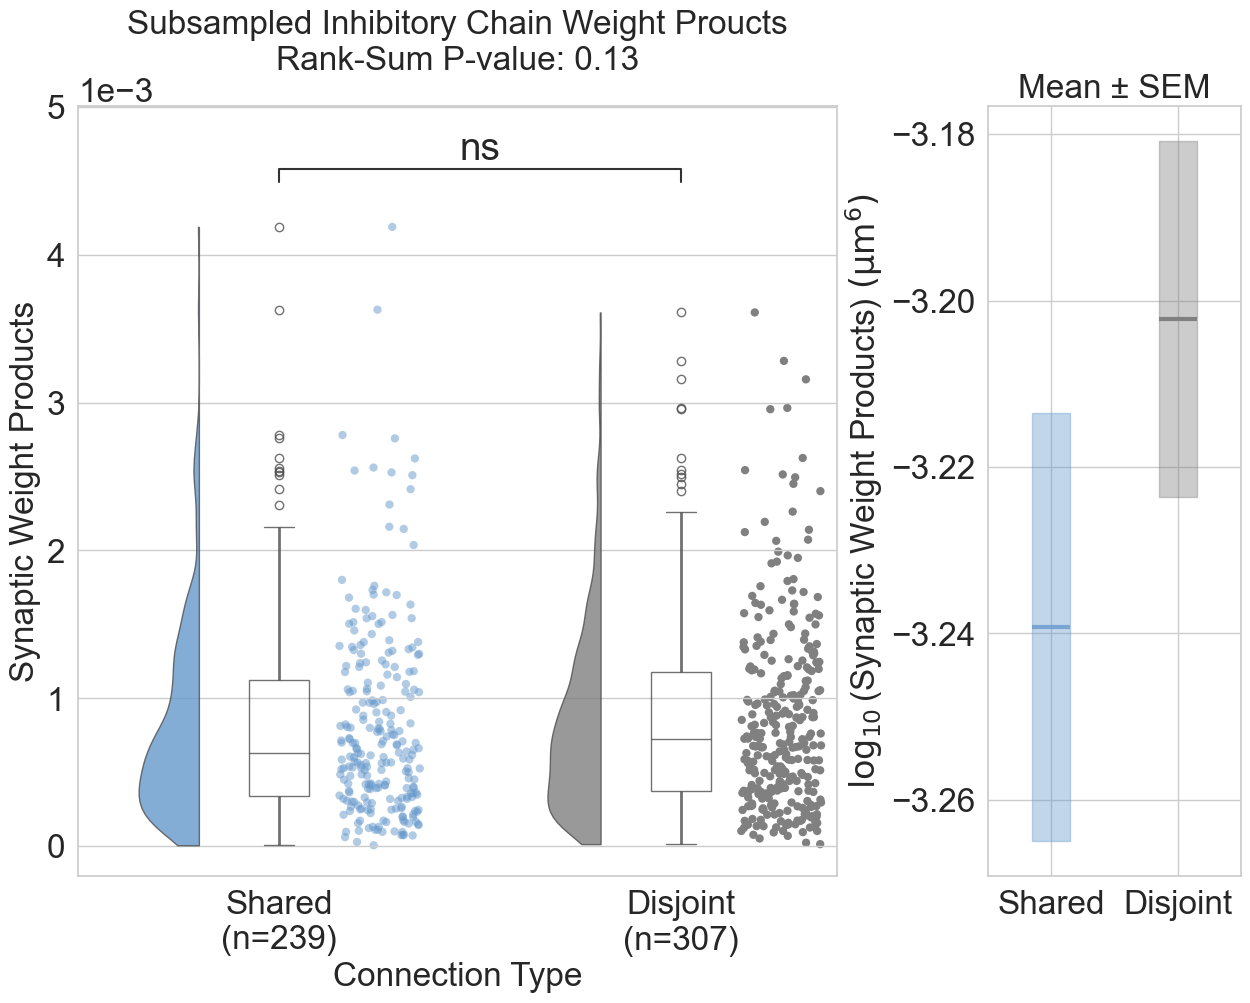


Resampling (B=10000) summary, resampling percentile CIs
Proportion significant (α=0.05): 0.209
HL shift median: 3.97e-05 (95% CI -3.92e-05–0.000115)
PS median: 0.523 (95% CI 0.478–0.566)
Cohen's d median: 0.0723 (95% CI -0.0823–0.226)
δ median: 0.0452 (95% CI -0.0445–0.132)


In [34]:
# ---------------- Helpers ----------------

def extract_vals_keys(dod):
    """Flatten dict-of-dicts into arrays (values) + arrays (keys) for each stratum."""
    vals, keys = {}, {}
    for k in ('shared', 'disjoint'):
        items = list(dod.get(k, {}).items())
        if items:
            k_arr, v_arr = zip(*items)         # tuples
            vals[k] = np.asarray(v_arr, dtype=float)
            keys[k] = np.asarray(k_arr, dtype=object)
        else:
            vals[k] = np.empty(0, float)
            keys[k] = np.empty(0, object)
    return vals, keys

def subsample_indices(n_avail, n_take, rng):
    if n_take > n_avail:
        raise ValueError(f"Requesting {n_take} from only {n_avail} available.")
    return rng.choice(n_avail, size=n_take, replace=False)

def build_dict_from_indices(keys, vals, idx_s, idx_d):
    """Rebuild dict-of-dicts for plotting/test function (keeps original (pre,post) keys)."""
    return {
        'shared':   {tuple(keys['shared'][i]): float(vals['shared'][i])     for i in idx_s},
        'disjoint': {tuple(keys['disjoint'][i]): float(vals['disjoint'][i]) for i in idx_d},
    }


def one_draw_stats(I_vals, n_shared, n_disjoint, rng):
    """One subsample: returns test results and effect sizes."""
    idx_s = subsample_indices(I_vals['shared'].size,   n_shared,   rng)
    idx_d = subsample_indices(I_vals['disjoint'].size, n_disjoint, rng)
    s = I_vals['shared'][idx_s]
    d = I_vals['disjoint'][idx_d]

    # Mann–Whitney U (direction shared < disjoint)
    U_s, p_mw = mannwhitneyu(s, d, alternative='less', method='asymptotic')
    n1, n2 = s.size, d.size
    delta = 1.0 - (2.0 * U_s) / (n1 * n2)

    # Other effect sizes
    d_cohen = cohens_d(s, d, alternative='less')
    HL = hodges_lehmann(s, d, alternative='less')
    PS, _ = ps_and_delta(s, d, alternative='less')

    return {
        "p": p_mw,
        "delta": delta,
        "d": d_cohen,
        "HL": HL,
        "PS": PS,
        "idx_s": idx_s,
        "idx_d": idx_d,
        "s": s,
        "d_vals": d,
    }


def resample_many(I_vals, n_shared, n_disjoint, B=10_000, rng=None):
    """Repeat subsampling many times: return arrays of effect sizes + p-values."""
    if rng is None:
        rng = default_rng()
    results = {"p": [], "delta": [], "d": [], "HL": [], "PS": []}
    for b in range(B):
        out = one_draw_stats(I_vals, n_shared, n_disjoint, rng)
        for k in results:
            results[k].append(out[k])
    return {k: np.array(v) for k, v in results.items()}


# ---------------- Subsampling Workflow ----------------

target = {'shared': 239, 'disjoint': 307}

# Flatten once
I_vals, I_keys = extract_vals_keys(W_chain_nonzero_pairwise_inhibitory)

# ---- One subsample ----
rng = default_rng(747)
one = one_draw_stats(I_vals, target['shared'], target['disjoint'], rng)
I_sub_for_plot = build_dict_from_indices(I_keys, I_vals, one['idx_s'], one['idx_d'])

print("SUBSAMPLED")
ranksum_signedrank_two_group_comparison(
    I_sub_for_plot,
    aggregation_method='connection',
    data_type='summed_psd',
    non_zero=True,
    chain_test=True,
    chain_description="Inhibitory",
    save=True,
    figure_name='Subsampled_Nonzero_PSD_by_Conn_I_Chain',
    title_prefix="Subsampled "
)

# ---- Many subsamples ----
B = 10_000
res = resample_many(I_vals, target['shared'], target['disjoint'], B=B, rng=rng)

alpha = 0.05
prop_sig = (res['p'] < alpha).mean()

def summarize(arr):
    return np.median(arr), np.percentile(arr, [2.5, 97.5])

HL_med, HL_ci = summarize(res['HL'])
PS_med, PS_ci = summarize(res['PS'])
d_med, d_ci = summarize(res['d'])
delta_med, delta_ci = summarize(res['delta'])

print(f"\nResampling (B={B}) summary, resampling percentile CIs")
print(f"Proportion significant (α={alpha}): {prop_sig:.3g}")
print(f"HL shift median: {HL_med:.3g} (95% CI {HL_ci[0]:.3g}–{HL_ci[1]:.3g})")
print(f"PS median: {PS_med:.3g} (95% CI {PS_ci[0]:.3g}–{PS_ci[1]:.3g})")
print(f"Cohen's d median: {d_med:.3g} (95% CI {d_ci[0]:.3g}–{d_ci[1]:.3g})")
print(f"δ median: {delta_med:.3g} (95% CI {delta_ci[0]:.3g}–{delta_ci[1]:.3g})")